# SSL Data Curation — przebadanie metody HKM (część 2: long-tail)

Notebook samowystarczalny, uruchamialny top-to-bottom na Kaggle (T4 x2).

**Logika:** Imagenette jest ~zbalansowane, więc HKM nie ma czego naprawiać i wychodzi
≈ Random (kontrola negatywna). Dlatego sztucznie wprowadzamy **długi ogon** (rozkład
potęgowy, headline **α=1.0**) i pokazujemy, że HKM odbudowuje balans i bije Random.
Główny dowód jest **pomiarowy** (rozkład klas wybranego podzbioru — entropia / KL do
uniform), a downstream go potwierdza (worst-class accuracy).

**Polityka „nie liczymy tego, co już mamy":** ciężkie artefakty (embeddingi DINO,
podzbiory zbalansowane, wagi scratcha, krzywe interpolacji) **ładujemy z dysku**.
Liczymy tylko: tanie embeddingi ResNet/Places365 + nowe eksperymenty na puli LT.

**Kurator (przestrzeń embeddingów do HKM):** w eksperymentach na puli LT (E2/E3/E6)
używamy **DINOv2** — modelu, który nigdy nie widział Imagenette (kurator agnostyczny
względem zadania, zgodnie z duchem artykułu).

| Sekcja | Eksperyment | Status |
|---|---|---|
| 0 | Setup | — |
| 1 | Wczytanie artefaktów | load |
| 2 | Ekstrakcja cech ResNet-ImageNet + Places365 | **nowe (tanie)** |
| 3 | E1: histogram klas + krzywe HKM≈Random (kontrola negatywna) | load + plot |
| 4 | E4: HKM-Places365 na zbalansowanej puli (dołożenie krzywej) | **nowe** |
| 5 | E2: pule LT + metryki balansu podzbioru (GŁÓWNY DOWÓD) | **nowe** |
| 6 | E3: downstream na puli LT (worst-class) | **nowe** |
| 7 | E5: najmocniejszy ewaluator (progressive unfreeze) na puli LT | **nowe** |
| 8 | E6: wizualizacja podzbioru na puli LT | **nowe** |
| 9 | Eksport | — |


## 0. Setup

In [2]:
# ── 0.1 Instalacja + dane ─────────────────────────────────────────────────────
import os
WORK_DIR = '/kaggle/working'
os.chdir(WORK_DIR)

!pip install torch torchvision tqdm scikit-learn pandas pillow tabulate -q
!wget -q https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz
!tar -xzf imagenette2-160.tgz
assert os.path.exists('imagenette2-160/train'), 'Brak danych!'
print('Dane OK.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 92.4 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

In [3]:
# ── 0.2 Importy + seed + GPU ──────────────────────────────────────────────────
import random, pickle
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights
import matplotlib.pyplot as plt

SEED = 42
def set_sampling_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_sampling_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

N_GPUS = torch.cuda.device_count()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'GPU: {N_GPUS}')
for i in range(N_GPUS):
    p = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {p.name} | {p.total_memory/1e9:.1f} GB')

GPU: 2
  GPU 0: Tesla T4 | 15.6 GB
  GPU 1: Tesla T4 | 15.6 GB


In [4]:
# ── 0.3 Transformacje + datasety + loadery ────────────────────────────────────
eval_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224), transforms.RandomHorizontalFlip(), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

train_feature_ds = datasets.ImageFolder('imagenette2-160/train', transform=eval_transform)
train_model_ds   = datasets.ImageFolder('imagenette2-160/train', transform=train_transform)
val_ds           = datasets.ImageFolder('imagenette2-160/val',   transform=eval_transform)

num_classes = len(train_feature_ds.classes)
CLASS_NAMES = train_feature_ds.classes
assert [p for p,_ in train_feature_ds.samples] == [p for p,_ in train_model_ds.samples]
assert np.array_equal(train_feature_ds.targets, train_model_ds.targets)

BATCH_SIZE  = 64 * max(N_GPUS, 1)
NUM_WORKERS = min(4 * max(N_GPUS, 1), os.cpu_count() or 4)

def make_loader(ds, shuffle, bs=BATCH_SIZE):
    return DataLoader(ds, batch_size=bs, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=True)

val_loader_exp = make_loader(val_ds, shuffle=False)
print(f'num_classes={num_classes} | batch={BATCH_SIZE} | workers={NUM_WORKERS}')

num_classes=10 | batch=128 | workers=4


## 1. Wczytanie zapisanych artefaktów

Ustaw `ARTIFACT_DIR` na katalog z plikami z poprzedniego notebooka (Kaggle dataset).
Wczytujemy: embeddingi DINO (train/val), `all_subsets.pkl`, `scratch_final_weights.pt`,
`exp_b_interpolation.csv`, `results_scratch.csv`.

Jeśli embeddingi DINO nie zostaną znalezione — komórka 1.2 (opcjonalna) wyliczy je
od nowa (wolne, ~6 min + 1.1 GB). Domyślnie zakładamy, że są na dysku.

In [5]:
# ── 1.1 Ścieżki + loader artefaktów ───────────────────────────────────────────
# EDYTUJ: katalog z artefaktami (np. '/kaggle/input/twoj-dataset')
ARTIFACT_DIR = '/kaggle/input/datasets/mateuszstasiak2115/dddssdsd/mati/mati'

def find_artifact(name):
    for base in (ARTIFACT_DIR, WORK_DIR, '.'):
        p = Path(base) / name
        if p.exists():
            return str(p)
    return None

art = {n: find_artifact(n) for n in [
    'train_embeddings.npy', 'train_labels_emb.npy',
    'val_embeddings.npy',   'val_labels_emb.npy',
    'all_subsets.pkl', 'scratch_final_weights.pt',
    'exp_b_interpolation.csv', 'results_scratch.csv']}
for k, v in art.items():
    print(f'  {"OK " if v else "BRAK"} {k}  {v or ""}')

  OK  train_embeddings.npy  /kaggle/input/datasets/mateuszstasiak2115/dddssdsd/mati/mati/train_embeddings.npy
  OK  train_labels_emb.npy  /kaggle/input/datasets/mateuszstasiak2115/dddssdsd/mati/mati/train_labels_emb.npy
  OK  val_embeddings.npy  /kaggle/input/datasets/mateuszstasiak2115/dddssdsd/mati/mati/val_embeddings.npy
  OK  val_labels_emb.npy  /kaggle/input/datasets/mateuszstasiak2115/dddssdsd/mati/mati/val_labels_emb.npy
  OK  all_subsets.pkl  /kaggle/input/datasets/mateuszstasiak2115/dddssdsd/mati/mati/all_subsets.pkl
  OK  scratch_final_weights.pt  /kaggle/input/datasets/mateuszstasiak2115/dddssdsd/mati/mati/scratch_final_weights.pt
  OK  exp_b_interpolation.csv  /kaggle/input/datasets/mateuszstasiak2115/dddssdsd/mati/mati/exp_b_interpolation.csv
  OK  results_scratch.csv  /kaggle/input/datasets/mateuszstasiak2115/dddssdsd/mati/mati/results_scratch.csv


In [6]:
# ── 1.2 (OPCJONALNE) Ekstrakcja DINO tylko jeśli brak embeddingów ─────────────
def extract_embeddings(loader, model, dev):
    all_emb, all_lab = [], []
    with torch.inference_mode():
        for images, labels in tqdm(loader, desc='DINO emb'):
            emb = model(images.to(dev, non_blocking=True))
            emb = F.normalize(emb, dim=1)
            all_emb.append(emb.cpu().numpy()); all_lab.extend(labels.numpy())
    return np.vstack(all_emb), np.array(all_lab)

if art['train_embeddings.npy'] is None or art['val_embeddings.npy'] is None:
    print('Brak embeddingów DINO — liczę od nowa (wolne).')
    dino = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14', verbose=False)
    if N_GPUS > 1: dino = nn.DataParallel(dino)
    dino = dino.to(device).eval()
    tr_emb, tr_lab = extract_embeddings(make_loader(train_feature_ds, False), dino, device)
    va_emb, va_lab = extract_embeddings(make_loader(val_ds, False), dino, device)
    np.save('train_embeddings.npy', tr_emb); np.save('train_labels_emb.npy', tr_lab)
    np.save('val_embeddings.npy', va_emb);   np.save('val_labels_emb.npy', va_lab)
    del dino; torch.cuda.empty_cache()
    for k in art: art[k] = art[k] or find_artifact(k)
    print('DINO embeddingi zapisane.')
else:
    print('Embeddingi DINO są na dysku — pomijam ekstrakcję.')

Embeddingi DINO są na dysku — pomijam ekstrakcję.


In [7]:
# ── 1.3 Załaduj embeddingi DINO + etykiety + walidacja zgodności ──────────────
train_embeddings = np.load(art['train_embeddings.npy'])
train_labels     = np.load(art['train_labels_emb.npy'])
val_embeddings   = np.load(art['val_embeddings.npy'])
val_labels       = np.load(art['val_labels_emb.npy'])

assert np.array_equal(train_labels, np.array(train_feature_ds.targets)), \
    'Etykiety DINO != kolejność datasetu! Sprawdź wersję imagenette / kolejność.'
assert np.array_equal(val_labels, np.array(val_ds.targets))
N_train = len(train_labels)
print(f'DINO train {train_embeddings.shape} | val {val_embeddings.shape} | N_train={N_train}')

# pozostałe artefakty
all_subsets = None
if art['all_subsets.pkl']:
    with open(art['all_subsets.pkl'], 'rb') as f:
        all_subsets = pickle.load(f)
    print('all_subsets.pkl: klucze =', sorted(set(k for k,_ in all_subsets.keys())))
exp_b_df = pd.read_csv(art['exp_b_interpolation.csv']) if art['exp_b_interpolation.csv'] else None
results_scratch_df = pd.read_csv(art['results_scratch.csv']) if art['results_scratch.csv'] else None

DINO train (9469, 1024) | val (3925, 1024) | N_train=9469
all_subsets.pkl: klucze = ['hkm_dino', 'hkm_resnet', 'random']


In [8]:
# ── 1.4 ssl-data-curation: klon + import ──────────────────────────────────────
!git clone https://github.com/facebookresearch/ssl-data-curation.git 2>/dev/null || echo 'juz sklonowane'
!pip install faiss-gpu-cu12 --no-deps -q 2>/dev/null || \
 pip install faiss-gpu --no-deps -q 2>/dev/null || echo 'faiss dostepny'
!cd ssl-data-curation && grep -v faiss requirements.txt > requirements_no_faiss.txt && \
 pip install -r requirements_no_faiss.txt -q

import sys
sys.path.insert(0, '/kaggle/working/ssl-data-curation')
np.Inf = np.inf  # shim dla starszego kodu
from src.clusters import HierarchicalCluster
from src import hierarchical_kmeans_gpu as hkmg, hierarchical_sampling as hs
print('ssl-data-curation OK.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 41.8 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.6/811.6 MB 2.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 1.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 90.4 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
ssl-data-curation OK.


### 1.5 Wspólne funkcje (modele, trening, HKM, metryki)

Jedna definicja każdej funkcji — bez duplikatów ze starego notebooka.

In [9]:
# ── Places365 weights loader ──────────────────────────────────────────────────
_PLACES_URL = 'http://places2.csail.mit.edu/models_places365/{model_id}_places365.pth.tar'

def _load_places365_state_dict(model_id, dev):
    ckpt = torch.hub.load_state_dict_from_url(_PLACES_URL.format(model_id=model_id),
                                              map_location=dev)
    return {k.replace('module.', ''): v for k, v in ckpt['state_dict'].items()}

# ── Fabryka modeli (imagenet / places365 / scratch) ──────────────────────────
def create_model(backbone, frozen=False):
    assert backbone in ('imagenet','places365','scratch')
    assert not (backbone=='scratch' and frozen)
    if backbone == 'imagenet':
        model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    elif backbone == 'places365':
        model = resnet50(weights=None)
        sd = _load_places365_state_dict('resnet50', device)
        sd = {k:v for k,v in sd.items() if not k.startswith('fc.')}
        model.load_state_dict(sd, strict=False)
    else:
        model = resnet50(weights=None)
    if frozen:
        for p in model.parameters(): p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    if N_GPUS > 1: model = nn.DataParallel(model)
    return model.to(device)

# ── Pętla treningowa / ewaluacja ──────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, frozen=False):
    if frozen:
        model.eval()
        base = model.module if isinstance(model, nn.DataParallel) else model
        base.fc.train()
    else:
        model.train()
    for images, labels in tqdm(loader, desc='train', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward(); optimizer.step()

def evaluate(model, loader, criterion):
    model.eval(); tot_loss=correct=total=0
    with torch.inference_mode():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            out = model(images); loss = criterion(out, labels)
            tot_loss += loss.item()*images.size(0)
            correct  += (out.argmax(1)==labels).sum().item()
            total    += labels.size(0)
    return tot_loss/total, correct/total

@torch.inference_mode()
def predict(model, loader):
    model.eval(); preds=[]; labs=[]
    for images, labels in loader:
        out = model(images.to(device, non_blocking=True))
        preds.append(out.argmax(1).cpu()); labs.append(labels)
    return torch.cat(preds).numpy(), torch.cat(labs).numpy()

def class_accuracies(preds, labels, n_classes=num_classes):
    correct = np.zeros(n_classes); total = np.zeros(n_classes)
    for l, p in zip(labels, preds):
        total[l] += 1; correct[l] += int(l == p)
    return np.divide(correct, total, out=np.full(n_classes, np.nan), where=total>0)

In [10]:
# ── HKM: budowa + samplowanie + skalowanie liczby klastrów ────────────────────
def scaled_n_clusters(pool_size, levels=3, pts_per_l1=10, ratio=3):
    n1 = max(pool_size // pts_per_l1, 30)
    n2 = max(n1 // ratio, 10)
    n3 = max(n2 // ratio, 4)
    return [n1, n2, n3][:levels]

def build_hkm(emb, n_clusters, sample_sizes=(5,3,2), n_levels=3, seed=SEED, dev='cuda:0'):
    set_sampling_seed(seed)
    data = torch.tensor(np.ascontiguousarray(emb), device=dev, dtype=torch.float32)
    cl = HierarchicalCluster.from_dict(
        hkmg.hierarchical_kmeans_with_resampling(
            data=data, n_clusters=list(n_clusters), n_levels=n_levels,
            sample_sizes=list(sample_sizes)[:n_levels], verbose=False))
    return cl

def validate_indices(indices, target, name):
    indices = np.asarray(indices, dtype=np.int64)
    assert len(np.unique(indices)) == len(indices), f'{name}: duplikaty'
    return indices

def hkm_subset(cl, target, seed=SEED):
    set_sampling_seed(seed)
    idx = hs.hierarchical_sampling(cl, target_size=target, sampling_strategy='r')
    return validate_indices(idx, target, 'HKM')

# ── Metryki balansu wybranego podzbioru (bez treningu) ────────────────────────
def balance_metrics(labels_subset, n_classes=num_classes):
    counts = np.bincount(np.asarray(labels_subset), minlength=n_classes).astype(float)
    p = counts / counts.sum()
    nz = p[p > 0]
    H = -(nz * np.log(nz)).sum()
    return {
        'entropy_norm':    H / np.log(n_classes),        # 1.0 = idealny balans
        'kl_to_uniform':   float((nz*np.log(nz*n_classes)).sum()),  # 0 = idealny
        'eff_n_classes':   float(np.exp(H)),
        'classes_covered': int((counts > 0).sum()),
        'max_min_ratio':   float(counts.max()/max(counts.min(),1)),
        'min_count':       int(counts.min()),
    }

## 2. Ekstrakcja cech ResNet-ImageNet + Places365 (tanie, ~1 min)

Potrzebne jako **przestrzeń kuracji** dla HKM-Places365 (E4) oraz do porównania
przestrzeni w pomiarze balansu na puli LT (E2, dodatek). Cechy z `avgpool` (2048-d),
**L2-normalizowane** (spójnie z DINO).

In [11]:
def build_feature_extractor(backbone):
    if backbone == 'imagenet':
        m = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    elif backbone == 'places365':
        m = resnet50(weights=None)
        sd = _load_places365_state_dict('resnet50', device)
        sd = {k:v for k,v in sd.items() if not k.startswith('fc.')}
        m.load_state_dict(sd, strict=False)
    m.fc = nn.Identity()
    if N_GPUS > 1: m = nn.DataParallel(m)
    return m.to(device).eval()

@torch.inference_mode()
def extract_feats(extractor, loader):
    feats, labs = [], []
    for images, labels in tqdm(loader, desc='feats'):
        f = extractor(images.to(device, non_blocking=True))
        f = F.normalize(f, dim=1)                  # L2-norm spójnie z DINO
        feats.append(f.cpu().numpy()); labs.append(labels.numpy())
    return np.concatenate(feats), np.concatenate(labs)

feat_loader = make_loader(train_feature_ds, shuffle=False)

ext_in = build_feature_extractor('imagenet')
resnet_feats, _ = extract_feats(ext_in, feat_loader)
del ext_in; torch.cuda.empty_cache()

ext_pl = build_feature_extractor('places365')
places_feats, _ = extract_feats(ext_pl, feat_loader)
del ext_pl; torch.cuda.empty_cache()

np.save('resnet_feats.npy', resnet_feats)
np.save('places_feats.npy', places_feats)
print('resnet_feats', resnet_feats.shape, '| places_feats', places_feats.shape)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s] 
feats: 100%|██████████| 74/74 [00:18<00:00,  3.94it/s]


Downloading: "http://places2.csail.mit.edu/models_places365/resnet50_places365.pth.tar" to /root/.cache/torch/hub/checkpoints/resnet50_places365.pth.tar


100%|██████████| 92.8M/92.8M [00:01<00:00, 62.6MB/s]
feats: 100%|██████████| 74/74 [00:16<00:00,  4.61it/s]


resnet_feats (9469, 2048) | places_feats (9469, 2048)


## 3. E1 — Kontrola negatywna (zbalansowana pula)

Pokazujemy, że (a) Imagenette ma ~jednostajny rozkład klas oraz (b) na takiej puli
HKM ≈ Random (krzywe z `exp_b_interpolation.csv`). To uzasadnia wprowadzenie ogona.

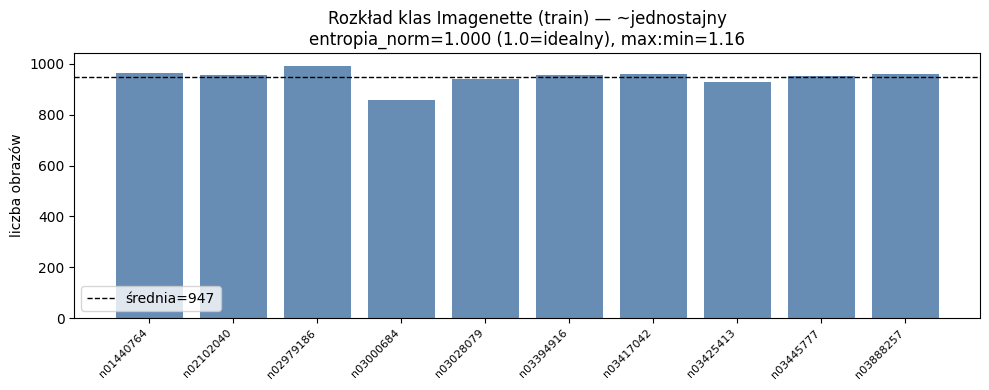

Balans puli zbalansowanej: {'entropy_norm': np.float64(0.999725492027441), 'kl_to_uniform': 0.0006320779655223942, 'eff_n_classes': 9.993681217536734, 'classes_covered': 10, 'max_min_ratio': 1.1573426573426573, 'min_count': 858}


In [14]:
# ── 3.1 Histogram rozkładu klas Imagenette (train) ────────────────────────────
counts = np.bincount(train_labels, minlength=num_classes)
bm = balance_metrics(train_labels)
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(range(num_classes), counts, color='#4e79a7', alpha=0.85)
ax.set_xticks(range(num_classes)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('liczba obrazów'); ax.axhline(counts.mean(), color='k', ls='--', lw=1, label=f'średnia={counts.mean():.0f}')
ax.set_title(f'Rozkład klas Imagenette (train) — ~jednostajny\n'
             f'entropia_norm={bm["entropy_norm"]:.3f} (1.0=idealny), max:min={bm["max_min_ratio"]:.2f}')
ax.legend(); plt.tight_layout(); plt.savefig('e1_class_hist_balanced.png', dpi=150, bbox_inches='tight'); plt.show()
print('Balans puli zbalansowanej:', bm)

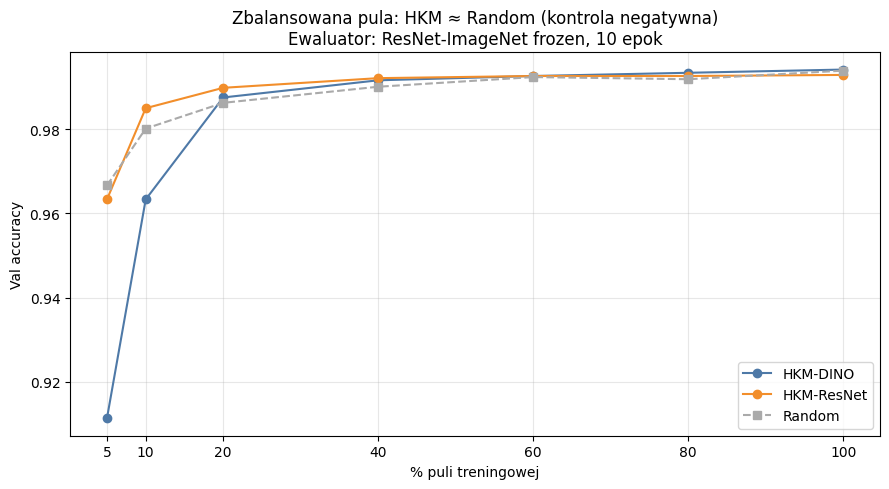

|   fraction |   n_samples |   hkm_dino_val_acc |   hkm_resnet_val_acc |   random_val_acc |
|-----------:|------------:|-------------------:|---------------------:|-----------------:|
|       0.05 |         473 |           0.911338 |             0.963312 |         0.966624 |
|       0.1  |         947 |           0.963312 |             0.984968 |         0.980127 |
|       0.2  |        1894 |           0.987516 |             0.989809 |         0.986242 |
|       0.4  |        3788 |           0.991592 |             0.992102 |         0.990064 |
|       0.6  |        5681 |           0.992611 |             0.992611 |         0.992357 |
|       0.8  |        7575 |           0.993376 |             0.992611 |         0.991847 |
|       1    |        9469 |           0.99414  |             0.992866 |         0.993885 |


In [15]:
# ── 3.2 Krzywe HKM≈Random na zbalansowanej puli (z artefaktu) ─────────────────
if exp_b_df is not None:
    pct = exp_b_df['fraction']*100
    fig, ax = plt.subplots(figsize=(9,5))
    ax.plot(pct, exp_b_df['hkm_dino_val_acc'],   'o-', color='#4e79a7', label='HKM-DINO')
    ax.plot(pct, exp_b_df['hkm_resnet_val_acc'], 'o-', color='#f28e2b', label='HKM-ResNet')
    ax.plot(pct, exp_b_df['random_val_acc'],     's--', color='#aaaaaa', label='Random')
    ax.set_xlabel('% puli treningowej'); ax.set_ylabel('Val accuracy'); ax.set_xticks(pct)
    ax.set_title('Zbalansowana pula: HKM ≈ Random (kontrola negatywna)\nEwaluator: ResNet-ImageNet frozen, 10 epok')
    ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('e1_balanced_curves.png', dpi=150, bbox_inches='tight'); plt.show()
    print(exp_b_df.to_markdown(index=False))
else:
    print('Brak exp_b_interpolation.csv — pomiń lub przelicz w starym notebooku.')

## 4. E4 — HKM-Places365 na zbalansowanej puli (dołożenie krzywej)

Trzecia przestrzeń kuracji obok DINO i ResNet (te dwie są już w `exp_b`).
Replikujemy dokładnie pipeline: HKM na cechach Places365 (znormalizowanych),
`n_clusters=[1000,300,100]`, `sample_sizes=[5,3,2]`, seed 42, ewaluator
ResNet-ImageNet frozen 10 epok. Te same frakcje co `exp_b`.

In [16]:
FRACTIONS = [0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.00]
EPOCHS_FROZEN = 10

def train_frozen_eval(indices, backbone='imagenet', epochs=EPOCHS_FROZEN):
    loader = make_loader(Subset(train_model_ds, indices), shuffle=True)
    model = create_model(backbone, frozen=True)
    crit = nn.CrossEntropyLoss()
    base = model.module if isinstance(model, nn.DataParallel) else model
    opt = torch.optim.AdamW(base.fc.parameters(), lr=1e-3, weight_decay=1e-4)
    for _ in range(epochs):
        train_one_epoch(model, loader, opt, crit, frozen=True)
    _, acc = evaluate(model, val_loader_exp, crit)
    del model, opt, crit, loader; torch.cuda.empty_cache()
    return acc

# Budowa HKM-Places365 na całej zbalansowanej puli
cl_places = build_hkm(places_feats, n_clusters=[1000,300,100], sample_sizes=(5,3,2))
print('HKM-Places365 zbudowany.')

places_curve = []
for frac in FRACTIONS:
    target = int(round(N_train*frac))
    idx = hkm_subset(cl_places, target)
    acc = train_frozen_eval(idx)
    places_curve.append(dict(fraction=frac, n_samples=target, hkm_places_val_acc=acc))
    print(f'  frac={frac:.0%} | HKM-Places365 acc={acc:.4f}')

places_df = pd.DataFrame(places_curve)
places_df.to_csv('e4_hkm_places_balanced.csv', index=False)
print(places_df.to_markdown(index=False))

Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:05<00:00,  1.71it/s]
HKM-Places365 zbudowany.
Hierarchical sampling from clusters: 100%|██████████| 100/100 [00:00<00:00, 2666.33it/s]


  frac=5% | HKM-Places365 acc=0.9692
Hierarchical sampling from clusters: 100%|██████████| 100/100 [00:00<00:00, 2841.84it/s]


  frac=10% | HKM-Places365 acc=0.9783
Hierarchical sampling from clusters: 100%|██████████| 100/100 [00:00<00:00, 2759.90it/s]


  frac=20% | HKM-Places365 acc=0.9862
Hierarchical sampling from clusters: 100%|██████████| 100/100 [00:00<00:00, 3142.86it/s]


  frac=40% | HKM-Places365 acc=0.9913
Hierarchical sampling from clusters: 100%|██████████| 100/100 [00:00<00:00, 5164.83it/s]


  frac=60% | HKM-Places365 acc=0.9916
Hierarchical sampling from clusters: 100%|██████████| 100/100 [00:00<00:00, 5186.48it/s]


  frac=80% | HKM-Places365 acc=0.9926
Hierarchical sampling from clusters: 100%|██████████| 100/100 [00:00<00:00, 9134.53it/s]


  frac=100% | HKM-Places365 acc=0.9929
|   fraction |   n_samples |   hkm_places_val_acc |
|-----------:|------------:|---------------------:|
|       0.05 |         473 |             0.969172 |
|       0.1  |         947 |             0.978344 |
|       0.2  |        1894 |             0.986242 |
|       0.4  |        3788 |             0.991338 |
|       0.6  |        5681 |             0.991592 |
|       0.8  |        7575 |             0.992611 |
|       1    |        9469 |             0.992866 |


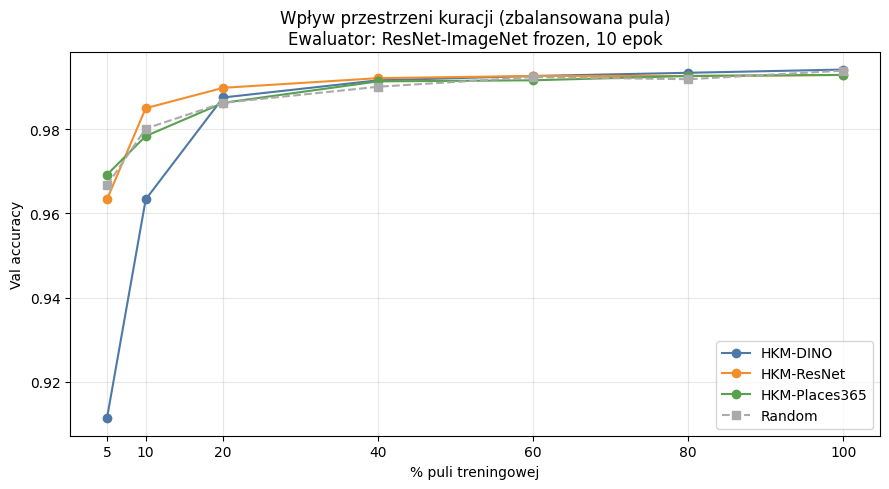

In [17]:
# ── 4.1 Wykres: 3 przestrzenie kuracji + Random na zbalansowanej puli ─────────
if exp_b_df is not None:
    pct = exp_b_df['fraction']*100
    fig, ax = plt.subplots(figsize=(9,5))
    ax.plot(pct, exp_b_df['hkm_dino_val_acc'],   'o-', color='#4e79a7', label='HKM-DINO')
    ax.plot(pct, exp_b_df['hkm_resnet_val_acc'], 'o-', color='#f28e2b', label='HKM-ResNet')
    ax.plot(places_df['fraction']*100, places_df['hkm_places_val_acc'], 'o-', color='#59a14f', label='HKM-Places365')
    ax.plot(pct, exp_b_df['random_val_acc'],     's--', color='#aaaaaa', label='Random')
    ax.set_xlabel('% puli treningowej'); ax.set_ylabel('Val accuracy'); ax.set_xticks(pct)
    ax.set_title('Wpływ przestrzeni kuracji (zbalansowana pula)\nEwaluator: ResNet-ImageNet frozen, 10 epok')
    ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('e4_curation_space_balanced.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. E2 — Pule long-tail + metryki balansu podzbioru  ⟵ GŁÓWNY DOWÓD

Wprowadzamy sztuczny długi ogon (rozkład potęgowy liczności klas). Dla każdego
budżetu mierzymy **rozkład klas wybranego podzbioru** — bez treningu. HKM (kurator:
**DINO**) powinien być bliżej rozkładu jednostajnego niż Random, który dziedziczy
imbalans puli. Headline **α=1.0**, wrażliwość: α∈{0.5, 1.0, 2.0}.

Selekcja jest **nienadzorowana** — HKM widzi tylko embeddingi. Etykiet używamy
wyłącznie do (a) zbudowania puli LT i (b) pomiaru balansu.

In [18]:
# ── 5.1 Budowa puli long-tail (power law) ─────────────────────────────────────
def make_longtailed_pool(labels, alpha, seed=SEED, rank_seed=0):
    labels = np.asarray(labels)
    classes = np.unique(labels)
    rng = np.random.default_rng(seed)
    order = np.random.default_rng(rank_seed).permutation(classes)  # losowe rangi (powtarzalne)
    n_max = max((labels==c).sum() for c in classes)
    keep, rank_of = [], {}
    for rank, c in enumerate(order, start=1):
        idx_c = np.where(labels==c)[0]
        target = min(int(round(n_max * rank**(-alpha))), len(idx_c))
        keep.append(rng.choice(idx_c, size=target, replace=False))
        rank_of[int(c)] = rank
    pool = np.sort(np.concatenate(keep))
    return pool, rank_of

ALPHAS = [0.5, 1.0, 2.0]
HEADLINE_ALPHA = 1.0
lt_pools = {}
for a in ALPHAS:
    pool, rank_of = make_longtailed_pool(train_labels, a)
    lt_pools[a] = dict(pool=pool, rank_of=rank_of)
    cc = np.bincount(train_labels[pool], minlength=num_classes)
    print(f'α={a}: |pula|={len(pool):5d} | klasy(min..max)={cc.min()}..{cc.max()} '
          f'| entropy_norm={balance_metrics(train_labels[pool])["entropy_norm"]:.3f}')

α=0.5: |pula|= 4932 | klasy(min..max)=314..941 | entropy_norm=0.972
α=1.0: |pula|= 2856 | klasy(min..max)=99..941 | entropy_norm=0.873
α=2.0: |pula|= 1487 | klasy(min..max)=10..941 | entropy_norm=0.549


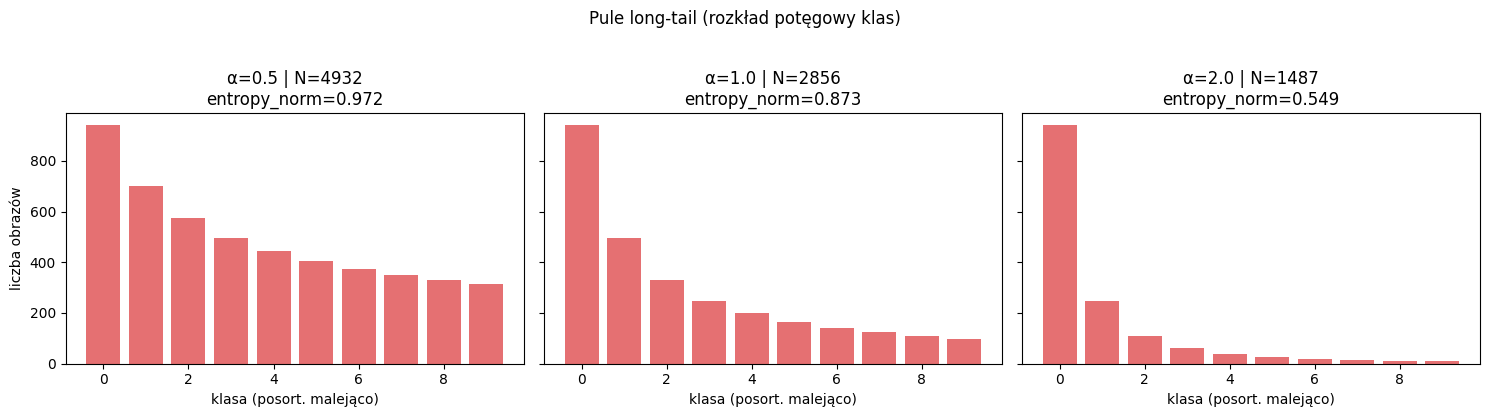

In [20]:
# ── 5.2 Histogramy pul LT ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(ALPHAS), figsize=(5*len(ALPHAS), 4), sharey=True)
for ax, a in zip(axes, ALPHAS):
    pool = lt_pools[a]['pool']
    cc = np.bincount(train_labels[pool], minlength=num_classes)
    order = np.argsort(-cc)
    ax.bar(range(num_classes), cc[order], color='#e15759', alpha=0.85)
    ax.set_title(f'α={a} | N={len(pool)}\nentropy_norm={balance_metrics(train_labels[pool])["entropy_norm"]:.3f}')
    ax.set_xlabel('klasa (posort. malejąco)')
axes[0].set_ylabel('liczba obrazów')
plt.suptitle('Pule long-tail (rozkład potęgowy klas)', y=1.03)
plt.tight_layout(); plt.savefig('e2_lt_pool_hist.png', dpi=150, bbox_inches='tight'); plt.show()

In [21]:
# ── 5.3 Metryki balansu podzbioru: HKM-DINO vs Random, wszystkie α ────────────
BUDGETS_LT = [0.10, 0.20, 0.40, 0.60]

balance_rows = []
for a in ALPHAS:
    pool = lt_pools[a]['pool']
    dino_pool = train_embeddings[pool]                      # kurator = DINO
    nclu = scaled_n_clusters(len(pool))
    cl_lt = build_hkm(dino_pool, n_clusters=nclu)
    rng = np.random.default_rng(SEED)
    random_order = rng.permutation(len(pool))
    print(f'α={a}: |pula|={len(pool)} | n_clusters={nclu}')
    for b in BUDGETS_LT:
        target = int(round(len(pool)*b))
        # HKM: indeksy lokalne w puli -> globalne; etykiety
        hkm_local = hkm_subset(cl_lt, target)
        hkm_lab   = train_labels[pool[hkm_local]]
        rnd_lab   = train_labels[pool[random_order[:target]]]
        for method, lab in [('HKM-DINO', hkm_lab), ('Random', rnd_lab)]:
            m = balance_metrics(lab)
            balance_rows.append(dict(alpha=a, budget=b, n_samples=target, method=method, **m))

balance_df = pd.DataFrame(balance_rows)
balance_df.to_csv('e2_balance_metrics.csv', index=False)
print(balance_df[balance_df.alpha==HEADLINE_ALPHA].to_markdown(index=False))

Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:03<00:00,  3.19it/s]
α=0.5: |pula|=4932 | n_clusters=[493, 164, 54]
Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:01<00:00,  5.26it/s]
α=1.0: |pula|=2856 | n_clusters=[285, 95, 31]
Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:01<00:00,  9.22it/s]
α=2.0: |pula|=1487 | n_clusters=[148, 49, 16]
Hierarchical sampling from clusters: 100%|██████████| 16/16 [00:00<00:00, 3270.89it/s]
|   alpha |   budget |   n_samples | method   |   entropy_norm |   kl_to_uniform |   eff_n_classes |   classes_covered |   max_min_ratio |   min_count |
|--------:|---------:|------------:|:---------|---------------:|----------------:|----------------:|------------------:|----------------:|------------:|
|       1 |      0.1 |         286 | HKM-DINO |       0.652499 |        0.800151 |         4.49261 |                10 |        42.6667  |           3 |
|       1 |      0.1 |         286 | Random   |       

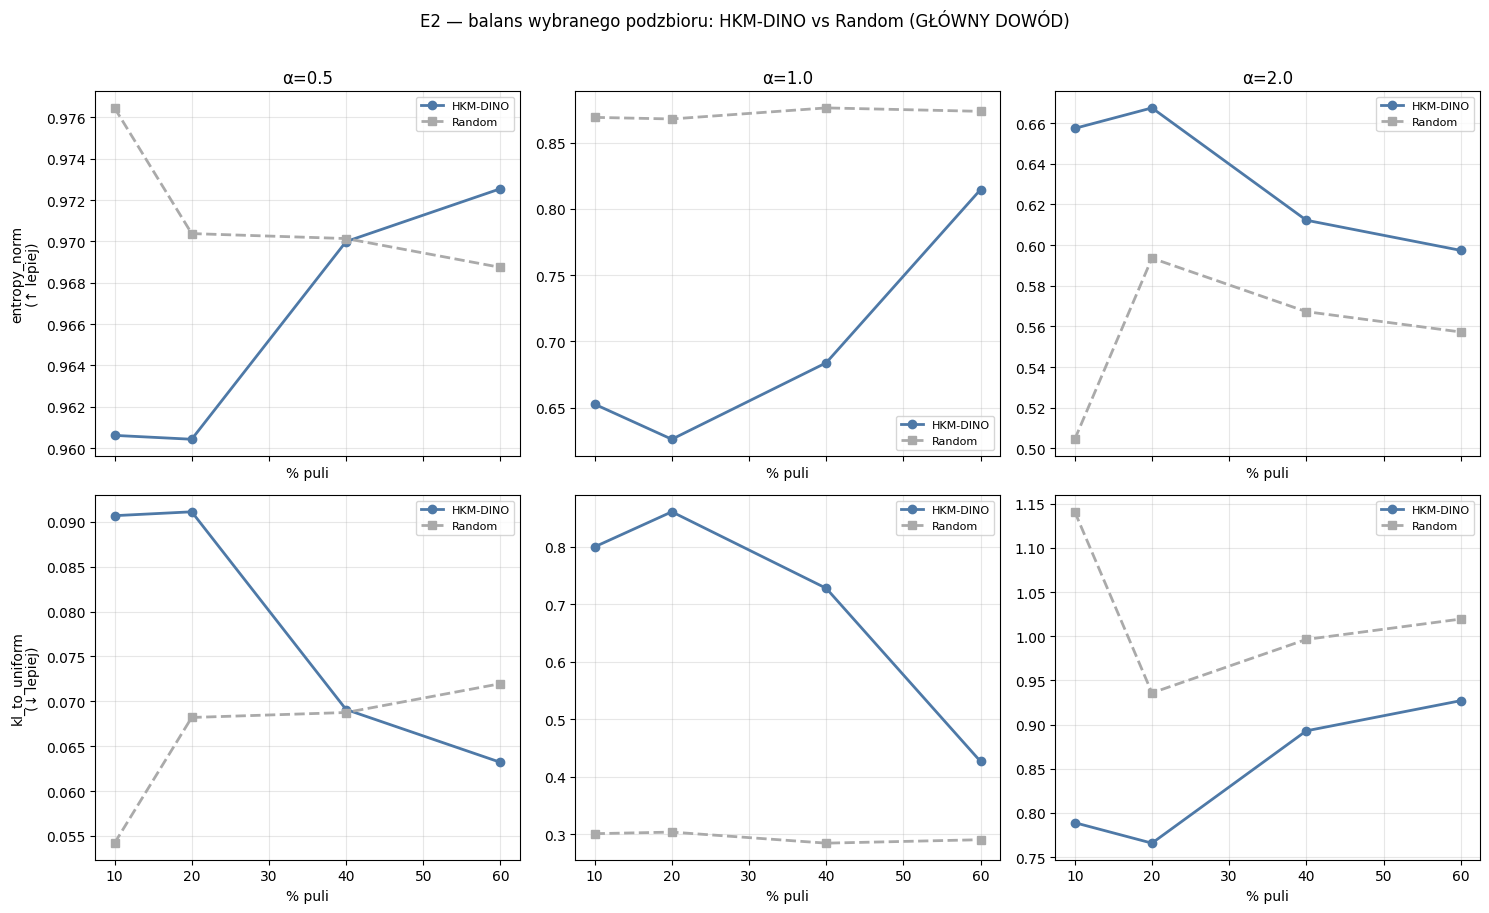

In [22]:
# ── 5.4 Wykresy: entropia i KL-do-uniform vs budżet (per α) ───────────────────
fig, axes = plt.subplots(2, len(ALPHAS), figsize=(5*len(ALPHAS), 9), sharex=True)
for col, a in enumerate(ALPHAS):
    sub = balance_df[balance_df.alpha==a]
    for metric, row, better in [('entropy_norm', 0, '↑ lepiej'), ('kl_to_uniform', 1, '↓ lepiej')]:
        ax = axes[row][col]
        for method, color, mk in [('HKM-DINO','#4e79a7','o'), ('Random','#aaaaaa','s')]:
            d = sub[sub.method==method].sort_values('budget')
            ax.plot(d.budget*100, d[metric], marker=mk, color=color, lw=2,
                    ls='-' if method=='HKM-DINO' else '--', label=method)
        if row==0: ax.set_title(f'α={a}')
        if col==0: ax.set_ylabel(f'{metric}\n({better})')
        ax.set_xlabel('% puli'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.suptitle('E2 — balans wybranego podzbioru: HKM-DINO vs Random (GŁÓWNY DOWÓD)', y=1.01)
plt.tight_layout(); plt.savefig('e2_balance_curves.png', dpi=150, bbox_inches='tight'); plt.show()

Hierarchical sampling from clusters: 100%|██████████| 31/31 [00:00<00:00, 5235.49it/s]


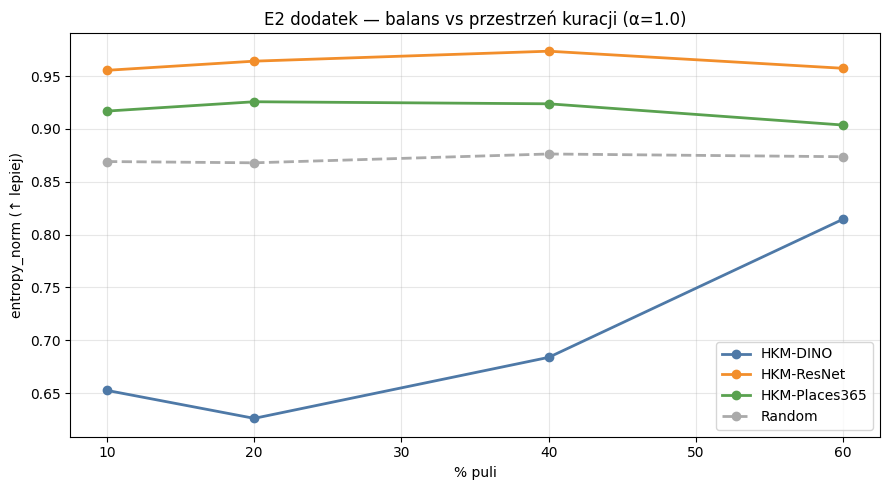

In [23]:
# ── 5.5 (dodatek pomiarowy) Wpływ przestrzeni kuracji na balans, α headline ──
# Tanie: tylko pomiar balansu, bez treningu. DINO vs ResNet vs Places365.
a = HEADLINE_ALPHA
pool = lt_pools[a]['pool']
nclu = scaled_n_clusters(len(pool))
spaces = {'HKM-DINO': train_embeddings[pool],
          'HKM-ResNet': resnet_feats[pool],
          'HKM-Places365': places_feats[pool]}
rng = np.random.default_rng(SEED); random_order = rng.permutation(len(pool))

rows = []
cls_built = {name: build_hkm(emb, n_clusters=nclu) for name, emb in spaces.items()}
for b in BUDGETS_LT:
    target = int(round(len(pool)*b))
    for name, cl_ in cls_built.items():
        lab = train_labels[pool[hkm_subset(cl_, target)]]
        rows.append(dict(budget=b, method=name, **balance_metrics(lab)))
    rows.append(dict(budget=b, method='Random',
                     **balance_metrics(train_labels[pool[random_order[:target]]])))
space_df = pd.DataFrame(rows); space_df.to_csv('e2_balance_by_space.csv', index=False)

fig, ax = plt.subplots(figsize=(9,5))
COL = {'HKM-DINO':'#4e79a7','HKM-ResNet':'#f28e2b','HKM-Places365':'#59a14f','Random':'#aaaaaa'}
for name, col in COL.items():
    d = space_df[space_df.method==name].sort_values('budget')
    ax.plot(d.budget*100, d.entropy_norm, marker='o', color=col, lw=2,
            ls='--' if name=='Random' else '-', label=name)
ax.set_xlabel('% puli'); ax.set_ylabel('entropy_norm (↑ lepiej)')
ax.set_title(f'E2 dodatek — balans vs przestrzeń kuracji (α={a})')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig('e2_balance_by_space.png', dpi=150, bbox_inches='tight'); plt.show()

## 6. E3 — Downstream na puli LT (worst-class)  ⟵ POTWIERDZENIE

Czy lepszy balans podzbioru przekłada się na lepsze cechy, zwłaszcza dla klas z ogona?
Headline α=1.0, budżety {10, 20, 40%}, kurator DINO, ewaluator ResNet-ImageNet frozen,
walidacja **zbalansowana** (val Imagenette). Metryki: overall, mean-per-class,
**worst-class**, oraz accuracy klas ogona. Jeden seed.

In [24]:
a = HEADLINE_ALPHA
pool = lt_pools[a]['pool']; rank_of = lt_pools[a]['rank_of']
tail_classes = [c for c,r in sorted(rank_of.items(), key=lambda kv: -kv[1])[:3]]  # 3 najmniej liczne
print('Klasy ogona (najmniej liczne w puli):', [CLASS_NAMES[c] for c in tail_classes])

nclu = scaled_n_clusters(len(pool))
cl_lt = build_hkm(train_embeddings[pool], n_clusters=nclu)
rng = np.random.default_rng(SEED); random_order = rng.permutation(len(pool))

def downstream_metrics(global_idx):
    loader = make_loader(Subset(train_model_ds, global_idx), shuffle=True)
    model = create_model('imagenet', frozen=True)
    crit = nn.CrossEntropyLoss()
    base = model.module if isinstance(model, nn.DataParallel) else model
    opt = torch.optim.AdamW(base.fc.parameters(), lr=1e-3, weight_decay=1e-4)
    for _ in range(EPOCHS_FROZEN):
        train_one_epoch(model, loader, opt, crit, frozen=True)
    preds, labs = predict(model, val_loader_exp)
    del model, opt, crit, loader; torch.cuda.empty_cache()
    ca = class_accuracies(preds, labs)
    return dict(overall=float((preds==labs).mean()),
                mean_per_class=float(np.nanmean(ca)),
                worst_class=float(np.nanmin(ca)),
                tail_acc=float(np.nanmean([ca[c] for c in tail_classes])))

e3_rows = []
for b in [0.10, 0.20, 0.40]:
    target = int(round(len(pool)*b))
    hkm_g = pool[hkm_subset(cl_lt, target)]
    rnd_g = pool[random_order[:target]]
    for method, g in [('HKM-DINO', hkm_g), ('Random', rnd_g)]:
        m = downstream_metrics(g)
        e3_rows.append(dict(alpha=a, budget=b, n_samples=target, method=method, **m))
        print(f'  b={b:.0%} {method:9s} overall={m["overall"]:.4f} '
              f'mean_pc={m["mean_per_class"]:.4f} worst={m["worst_class"]:.4f} tail={m["tail_acc"]:.4f}')

e3_df = pd.DataFrame(e3_rows); e3_df.to_csv('e3_downstream_lt.csv', index=False)
print(e3_df.to_markdown(index=False))

Klasy ogona (najmniej liczne w puli): ['n02102040', 'n03445777', 'n01440764']
Hierarchical sampling from clusters: 100%|██████████| 31/31 [00:00<00:00, 2266.68it/s]


  b=10% HKM-DINO  overall=0.3225 mean_pc=0.3281 worst=0.0000 tail=0.0981


  b=10% Random    overall=0.7478 mean_pc=0.7490 worst=0.2979 tail=0.7466
Hierarchical sampling from clusters: 100%|██████████| 31/31 [00:00<00:00, 2793.62it/s]


  b=20% HKM-DINO  overall=0.5518 mean_pc=0.5579 worst=0.0000 tail=0.4938


  b=20% Random    overall=0.9218 mean_pc=0.9227 worst=0.7068 tail=0.8894
Hierarchical sampling from clusters: 100%|██████████| 31/31 [00:00<00:00, 3399.22it/s]


  b=40% HKM-DINO  overall=0.8150 mean_pc=0.8197 worst=0.2267 tail=0.8985


  b=40% Random    overall=0.9730 mean_pc=0.9733 worst=0.9189 tail=0.9815
|   alpha |   budget |   n_samples | method   |   overall |   mean_per_class |   worst_class |   tail_acc |
|--------:|---------:|------------:|:---------|----------:|-----------------:|--------------:|-----------:|
|       1 |      0.1 |         286 | HKM-DINO |  0.322548 |         0.328109 |      0        |  0.0980996 |
|       1 |      0.1 |         286 | Random   |  0.747771 |         0.749008 |      0.297927 |  0.746609  |
|       1 |      0.2 |         571 | HKM-DINO |  0.551847 |         0.557947 |      0        |  0.493755  |
|       1 |      0.2 |         571 | Random   |  0.921783 |         0.922703 |      0.706767 |  0.88944   |
|       1 |      0.4 |        1142 | HKM-DINO |  0.815032 |         0.819711 |      0.22673  |  0.898517  |
|       1 |      0.4 |        1142 | Random   |  0.972994 |         0.973314 |      0.918854 |  0.981509  |


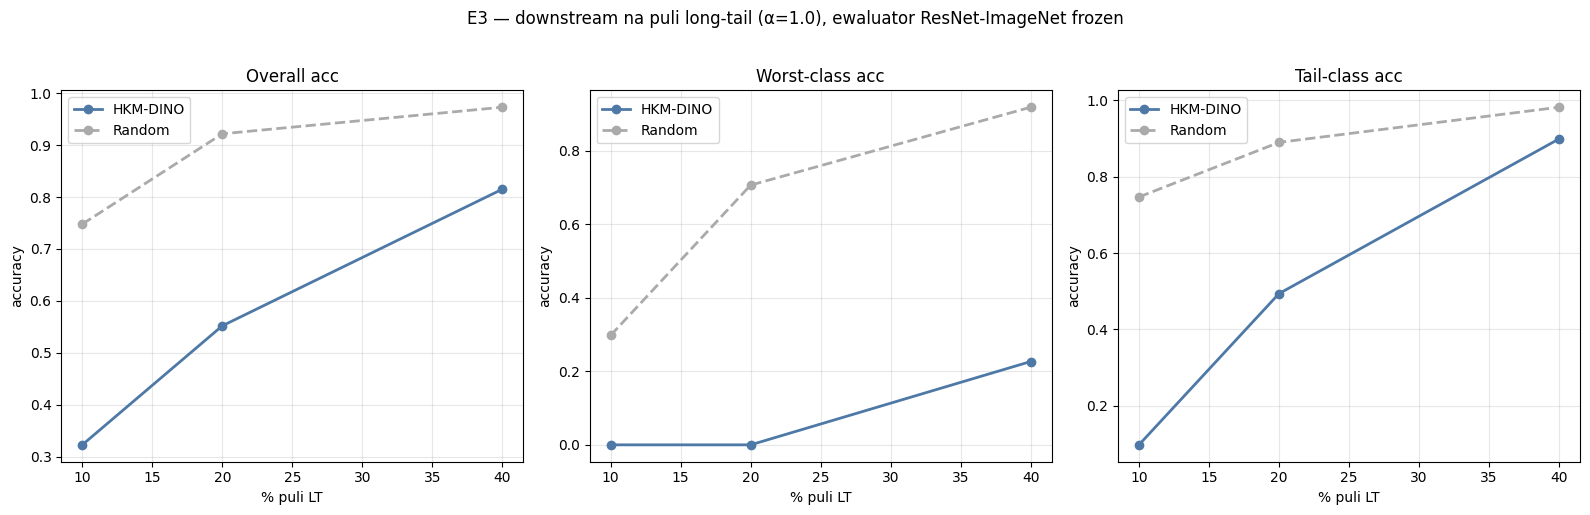

In [26]:
# ── 6.1 Wykres: worst-class i tail vs budżet ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, metric, title in zip(axes, ['overall','worst_class','tail_acc'],
                             ['Overall acc','Worst-class acc','Tail-class acc']):
    for method, col, ls in [('HKM-DINO','#4e79a7','-'), ('Random','#aaaaaa','--')]:
        d = e3_df[e3_df.method==method].sort_values('budget')
        ax.plot(d.budget*100, d[metric], marker='o', color=col, ls=ls, lw=2, label=method)
    ax.set_title(title); ax.set_xlabel('% puli LT'); ax.set_ylabel('accuracy')
    ax.grid(alpha=0.3); ax.legend()
plt.suptitle(f'E3 — downstream na puli long-tail (α={a}), ewaluator ResNet-ImageNet frozen', y=1.02)
plt.tight_layout(); plt.savefig('e3_downstream_lt.png', dpi=150, bbox_inches='tight'); plt.show()

## 7. E5 — Najmocniejszy ewaluator na puli LT (progressive unfreeze)

Sprawdzamy, czy wniosek trzyma się przy mocniejszym ewaluatorze. Bierzemy backbone
scratch (z `scratch_final_weights.pt`) i odmrażamy `fc+layer4+layer3+layer2` — wariant,
który w starych eksperymentach dawał najlepszy wynik. Pula LT α=1.0, budżet 20%,
HKM-DINO vs Random.

In [ ]:
UNFREEZE = ['fc','layer4','layer3','layer2']
LAYER_LR = {'layer1':1e-5,'layer2':1e-5,'layer3':1e-4,'layer4':1e-4,'fc':1e-3}

def load_scratch_unfreeze(unfreeze_layers):
    assert art['scratch_final_weights.pt'], 'Brak scratch_final_weights.pt'
    model = create_model('scratch', frozen=False)
    base = model.module if isinstance(model, nn.DataParallel) else model
    base.load_state_dict(torch.load(art['scratch_final_weights.pt'], map_location=device))
    for p in base.parameters(): p.requires_grad = False
    for ln in unfreeze_layers:
        for p in getattr(base, ln).parameters(): p.requires_grad = True
    return model.to(device)

def run_unfreeze(global_idx, epochs=EPOCHS_FROZEN):
    loader = make_loader(Subset(train_model_ds, global_idx), shuffle=True)
    model = load_scratch_unfreeze(UNFREEZE)
    base = model.module if isinstance(model, nn.DataParallel) else model
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.AdamW([{'params':getattr(base,l).parameters(),'lr':LAYER_LR[l]}
                             for l in UNFREEZE], weight_decay=1e-4)
    best = 0.0
    for _ in range(epochs):
        train_one_epoch(model, loader, opt, crit, frozen=False)
        _, acc = evaluate(model, val_loader_exp, crit); best = max(best, acc)
    del model, opt, crit, loader; torch.cuda.empty_cache()
    return best

a = HEADLINE_ALPHA; pool = lt_pools[a]['pool']
nclu = scaled_n_clusters(len(pool)); cl_lt = build_hkm(train_embeddings[pool], n_clusters=nclu)
rng = np.random.default_rng(SEED); random_order = rng.permutation(len(pool))
target = int(round(len(pool)*0.20))

e5_rows = []
for method, g in [('HKM-DINO', pool[hkm_subset(cl_lt, target)]),
                  ('Random',   pool[random_order[:target]])]:
    acc = run_unfreeze(g)
    e5_rows.append(dict(alpha=a, budget=0.20, method=method, config='+'.join(UNFREEZE), best_val_acc=acc))
    print(f'  {method:9s} best_val_acc={acc:.4f}')
e5_df = pd.DataFrame(e5_rows); e5_df.to_csv('e5_unfreeze_lt.csv', index=False)
print(e5_df.to_markdown(index=False))

## 8. E6 — Wizualizacja podzbioru na puli LT

t-SNE embeddingów DINO ograniczonych do puli LT (α=1.0). Nakładamy wybrany podzbiór
(HKM-DINO 20% vs Random 20%) oraz histogramy klas obu podzbiorów — wizualnie:
HKM „rozlewa" pobór równomiernie, Random kopiuje imbalans puli.

Hierarchical sampling from clusters: 100%|██████████| 31/31 [00:00<00:00, 2918.53it/s]
t-SNE puli LT...


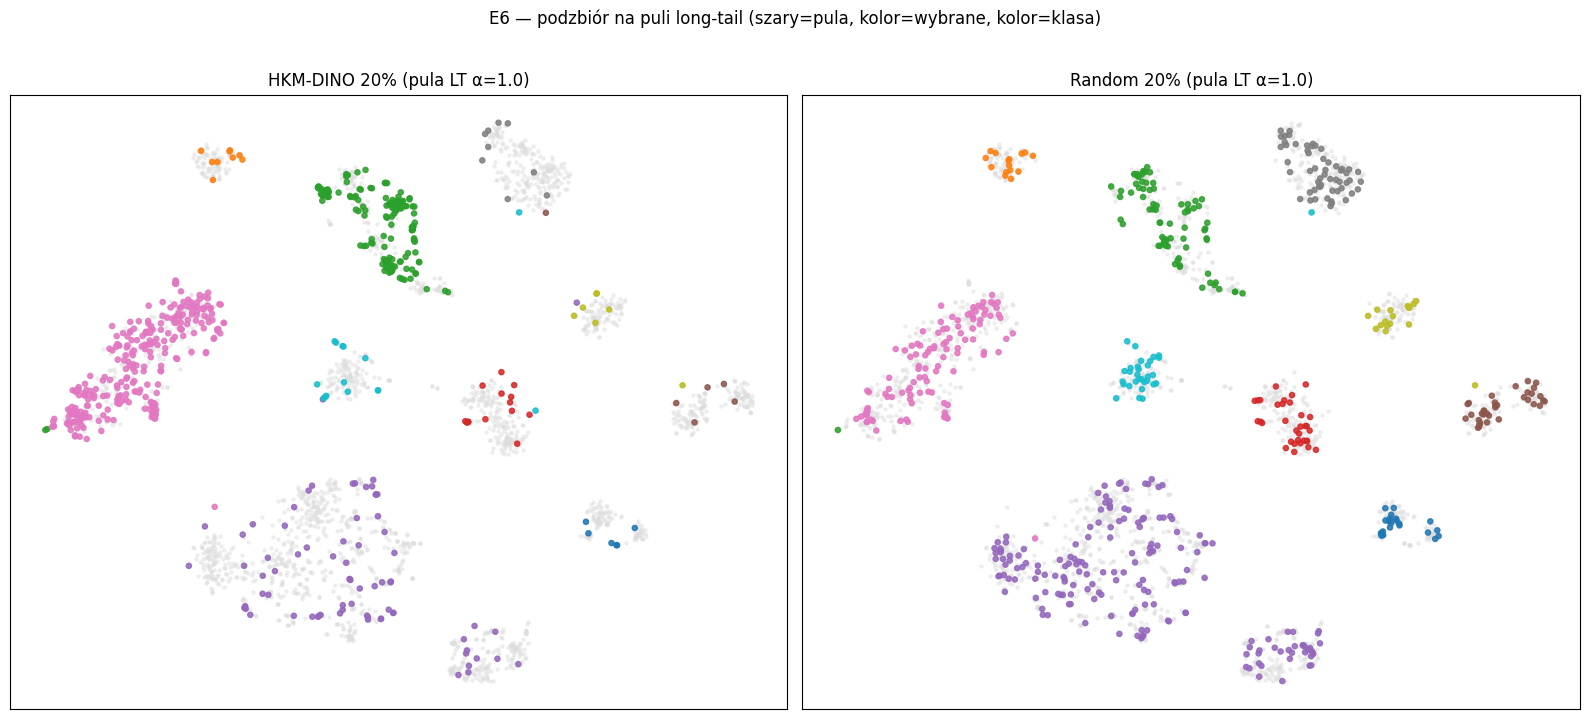

In [27]:
from sklearn.manifold import TSNE
a = HEADLINE_ALPHA; pool = lt_pools[a]['pool']
dino_pool = train_embeddings[pool]; lab_pool = train_labels[pool]
nclu = scaled_n_clusters(len(pool)); cl_lt = build_hkm(dino_pool, n_clusters=nclu)
rng = np.random.default_rng(SEED); random_order = rng.permutation(len(pool))
target = int(round(len(pool)*0.20))
hkm_local = hkm_subset(cl_lt, target); rnd_local = random_order[:target]

print('t-SNE puli LT...')
emb2d = TSNE(n_components=2, perplexity=40, random_state=SEED, n_jobs=-1).fit_transform(dino_pool)

fig, axes = plt.subplots(1, 2, figsize=(16,7))
for ax, local_idx, title in [(axes[0], hkm_local, 'HKM-DINO 20%'),
                             (axes[1], rnd_local, 'Random 20%')]:
    ax.scatter(emb2d[:,0], emb2d[:,1], c='#dddddd', s=5, alpha=0.4)
    sc = ax.scatter(emb2d[local_idx,0], emb2d[local_idx,1],
                    c=lab_pool[local_idx], cmap='tab10', s=14, alpha=0.85, vmin=0, vmax=9)
    ax.set_title(f'{title} (pula LT α={a})'); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('E6 — podzbiór na puli long-tail (szary=pula, kolor=wybrane, kolor=klasa)', y=1.02)
plt.tight_layout(); plt.savefig('e6_tsne_lt_subset.png', dpi=150, bbox_inches='tight'); plt.show()

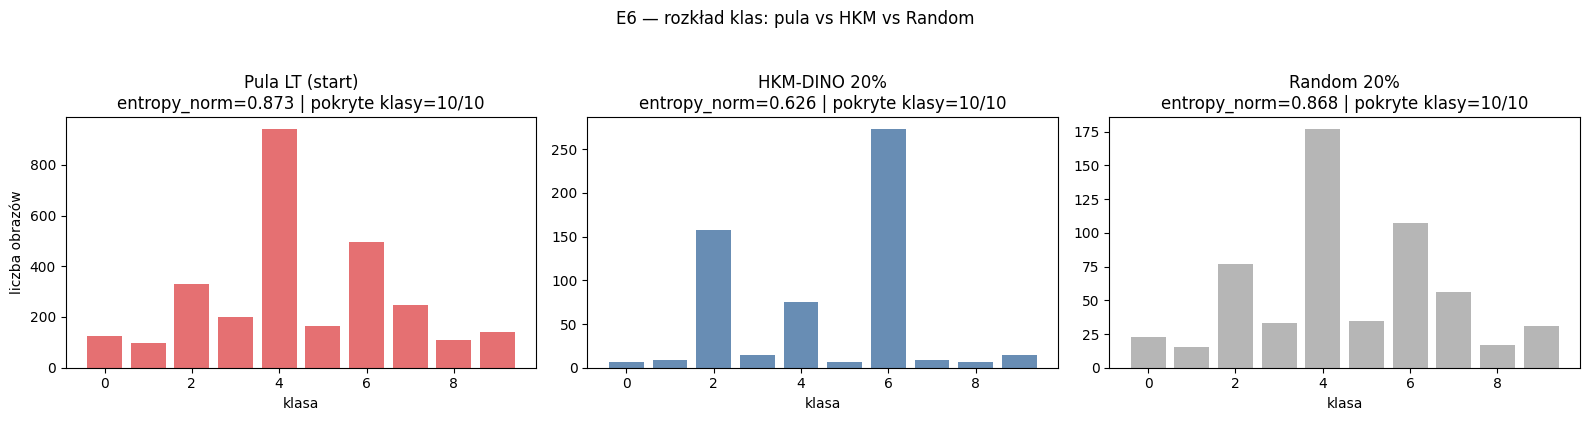

In [28]:
# ── 8.1 Histogramy klas wybranych podzbiorów vs pula ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16,4), sharey=False)
for ax, lab, title, col in [
    (axes[0], lab_pool,                'Pula LT (start)',  '#e15759'),
    (axes[1], lab_pool[hkm_local],     'HKM-DINO 20%',     '#4e79a7'),
    (axes[2], lab_pool[rnd_local],     'Random 20%',       '#aaaaaa')]:
    cc = np.bincount(lab, minlength=num_classes)
    ax.bar(range(num_classes), cc, color=col, alpha=0.85)
    bm = balance_metrics(lab)
    ax.set_title(f'{title}\nentropy_norm={bm["entropy_norm"]:.3f} | pokryte klasy={bm["classes_covered"]}/{num_classes}')
    ax.set_xlabel('klasa')
axes[0].set_ylabel('liczba obrazów')
plt.suptitle('E6 — rozkład klas: pula vs HKM vs Random', y=1.04)
plt.tight_layout(); plt.savefig('e6_subset_hist_lt.png', dpi=150, bbox_inches='tight'); plt.show()

In [31]:
# ── P1. Metryki balansu podzbioru: HKM-Places365 vs Random, wszystkie α ────────
BUDGETS_LT_PLACES = [0.10, 0.20, 0.40, 0.60]

balance_places_rows = []

for a in ALPHAS:
    pool = lt_pools[a]['pool']

    # Najważniejsza zmiana względem poprzedniego eksperymentu:
    # HKM budujemy w przestrzeni embeddingów Places365 zamiast DINO.
    places_pool = places_feats[pool]

    nclu = scaled_n_clusters(len(pool))
    cl_lt_places = build_hkm(places_pool, n_clusters=nclu)

    rng = np.random.default_rng(SEED)
    random_order = rng.permutation(len(pool))

    print(f'α={a}: |pula|={len(pool)} | n_clusters={nclu}')

    for b in BUDGETS_LT_PLACES:
        target = int(round(len(pool) * b))

        # Indeksy zwracane przez hkm_subset są lokalne względem puli LT.
        hkm_local = hkm_subset(cl_lt_places, target)

        hkm_lab = train_labels[pool[hkm_local]]
        rnd_lab = train_labels[pool[random_order[:target]]]

        for method, lab in [
            ('HKM-Places365', hkm_lab),
            ('Random', rnd_lab)
        ]:
            m = balance_metrics(lab)

            balance_places_rows.append(
                dict(
                    alpha=a,
                    budget=b,
                    n_samples=target,
                    method=method,
                    **m
                )
            )

balance_places_df = pd.DataFrame(balance_places_rows)

balance_places_df.to_csv(
    'e2_balance_metrics_places365.csv',
    index=False
)

print(
    balance_places_df[
        balance_places_df.alpha == HEADLINE_ALPHA
    ].to_markdown(index=False)
)

Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:03<00:00,  3.08it/s]
α=0.5: |pula|=4932 | n_clusters=[493, 164, 54]
Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:01<00:00,  5.23it/s]
α=1.0: |pula|=2856 | n_clusters=[285, 95, 31]
Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:01<00:00,  9.19it/s]
α=2.0: |pula|=1487 | n_clusters=[148, 49, 16]
Hierarchical sampling from clusters: 100%|██████████| 16/16 [00:00<00:00, 4339.40it/s]
|   alpha |   budget |   n_samples | method        |   entropy_norm |   kl_to_uniform |   eff_n_classes |   classes_covered |   max_min_ratio |   min_count |
|--------:|---------:|------------:|:--------------|---------------:|----------------:|----------------:|------------------:|----------------:|------------:|
|       1 |      0.1 |         286 | HKM-Places365 |       0.91688  |        0.191391 |         8.2581  |                10 |        11.1667  |           6 |
|       1 |      0.1 |         286 | Ra

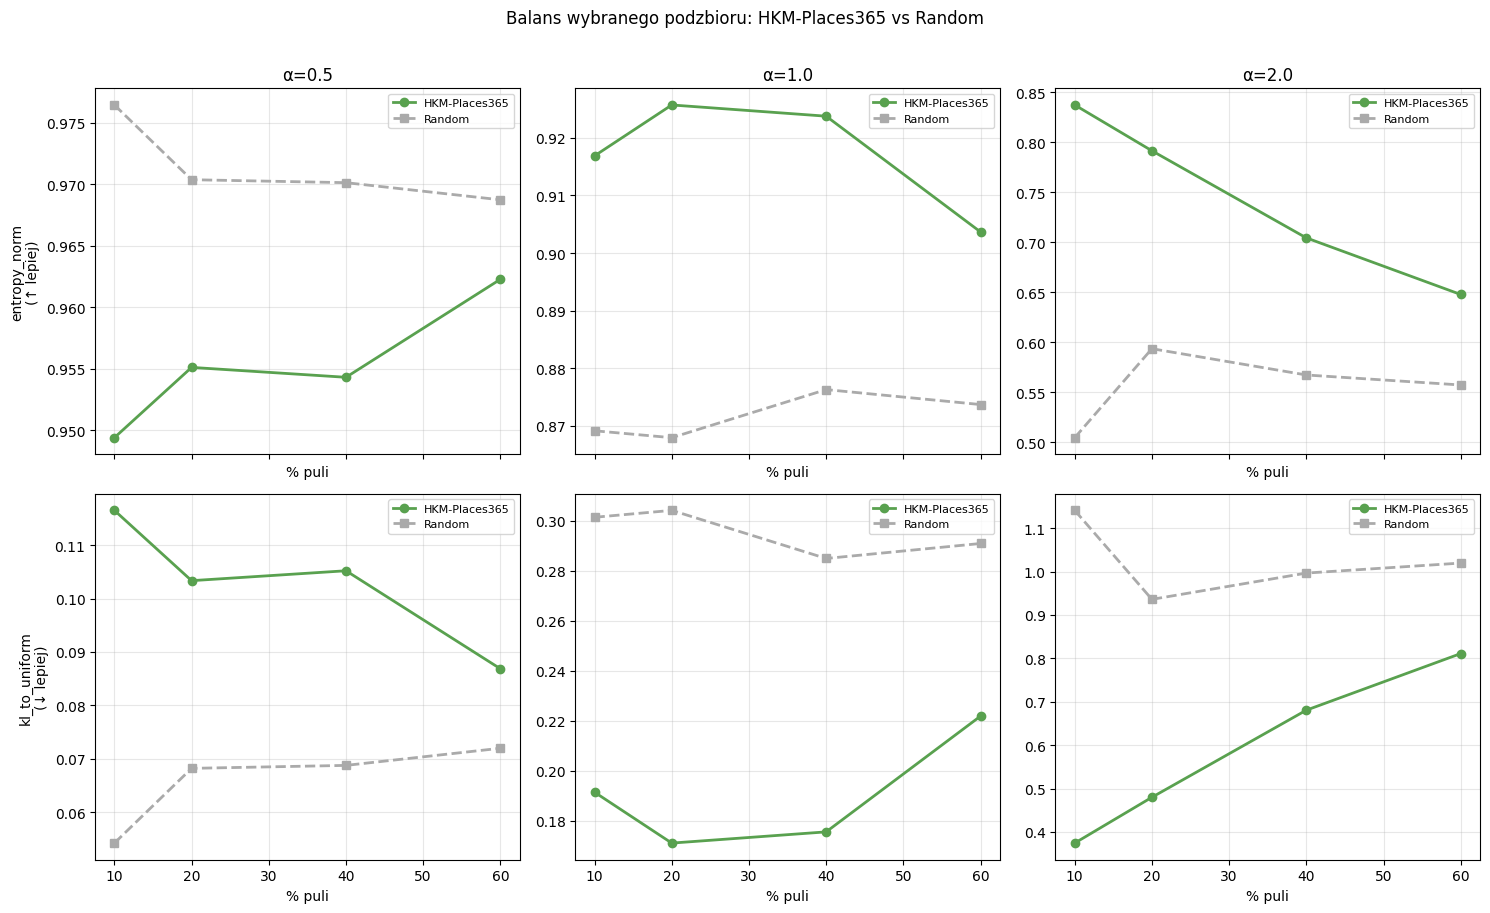

In [32]:
# ── P2. Wykresy balansu: entropia i KL-do-uniform vs budżet ───────────────────
fig, axes = plt.subplots(
    2,
    len(ALPHAS),
    figsize=(5 * len(ALPHAS), 9),
    sharex=True
)

for col, a in enumerate(ALPHAS):
    sub = balance_places_df[balance_places_df.alpha == a]

    for metric, row, better in [
        ('entropy_norm', 0, '↑ lepiej'),
        ('kl_to_uniform', 1, '↓ lepiej')
    ]:
        ax = axes[row][col]

        for method, color, marker in [
            ('HKM-Places365', '#59a14f', 'o'),
            ('Random', '#aaaaaa', 's')
        ]:
            d = sub[sub.method == method].sort_values('budget')

            ax.plot(
                d.budget * 100,
                d[metric],
                marker=marker,
                color=color,
                lw=2,
                ls='-' if method == 'HKM-Places365' else '--',
                label=method
            )

        if row == 0:
            ax.set_title(f'α={a}')

        if col == 0:
            ax.set_ylabel(f'{metric}\n({better})')

        ax.set_xlabel('% puli')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

plt.suptitle(
    'Balans wybranego podzbioru: HKM-Places365 vs Random',
    y=1.01
)

plt.tight_layout()

plt.savefig(
    'e2_balance_curves_places365.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [33]:
# ── P3. Downstream na puli LT: HKM-Places365 vs Random ────────────────────────
a = HEADLINE_ALPHA

pool = lt_pools[a]['pool']
rank_of = lt_pools[a]['rank_of']

# Trzy najmniej liczne klasy w puli long-tail.
tail_classes_places = [
    c
    for c, r in sorted(
        rank_of.items(),
        key=lambda kv: -kv[1]
    )[:3]
]

print(
    'Klasy ogona (najmniej liczne w puli):',
    [CLASS_NAMES[c] for c in tail_classes_places]
)

nclu = scaled_n_clusters(len(pool))

# Kurator = Places365.
cl_lt_places = build_hkm(
    places_feats[pool],
    n_clusters=nclu
)

rng = np.random.default_rng(SEED)
random_order = rng.permutation(len(pool))


def downstream_metrics_places365(global_idx):
    """
    Trening liniowego klasyfikatora na wybranym podzbiorze.
    Backbone ewaluatora: ResNet-ImageNet frozen.
    """
    loader = make_loader(
        Subset(train_model_ds, global_idx),
        shuffle=True
    )

    model = create_model('imagenet', frozen=True)

    crit = nn.CrossEntropyLoss()

    base = (
        model.module
        if isinstance(model, nn.DataParallel)
        else model
    )

    opt = torch.optim.AdamW(
        base.fc.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )

    for _ in range(EPOCHS_FROZEN):
        train_one_epoch(
            model,
            loader,
            opt,
            crit,
            frozen=True
        )

    preds, labs = predict(model, val_loader_exp)

    del model, opt, crit, loader
    torch.cuda.empty_cache()

    class_acc = class_accuracies(preds, labs)

    return dict(
        overall=float((preds == labs).mean()),
        mean_per_class=float(np.nanmean(class_acc)),
        worst_class=float(np.nanmin(class_acc)),
        tail_acc=float(
            np.nanmean(
                [class_acc[c] for c in tail_classes_places]
            )
        )
    )


e3_places_rows = []

for b in [0.10, 0.20, 0.40]:
    target = int(round(len(pool) * b))

    hkm_global = pool[
        hkm_subset(cl_lt_places, target)
    ]

    rnd_global = pool[
        random_order[:target]
    ]

    for method, global_idx in [
        ('HKM-Places365', hkm_global),
        ('Random', rnd_global)
    ]:
        metrics = downstream_metrics_places365(global_idx)

        e3_places_rows.append(
            dict(
                alpha=a,
                budget=b,
                n_samples=target,
                method=method,
                **metrics
            )
        )

        print(
            f'  b={b:.0%} '
            f'{method:13s} '
            f'overall={metrics["overall"]:.4f} '
            f'mean_pc={metrics["mean_per_class"]:.4f} '
            f'worst={metrics["worst_class"]:.4f} '
            f'tail={metrics["tail_acc"]:.4f}'
        )

e3_places_df = pd.DataFrame(e3_places_rows)

e3_places_df.to_csv(
    'e3_downstream_lt_places365.csv',
    index=False
)

print(e3_places_df.to_markdown(index=False))

Klasy ogona (najmniej liczne w puli): ['n02102040', 'n03445777', 'n01440764']
Hierarchical sampling from clusters: 100%|██████████| 31/31 [00:00<00:00, 2491.06it/s]


  b=10% HKM-Places365 overall=0.7417 mean_pc=0.7473 worst=0.0000 tail=0.9075


  b=10% Random        overall=0.7478 mean_pc=0.7490 worst=0.2979 tail=0.7466
Hierarchical sampling from clusters: 100%|██████████| 31/31 [00:00<00:00, 2631.25it/s]


  b=20% HKM-Places365 overall=0.8517 mean_pc=0.8573 worst=0.1026 tail=0.9741


  b=20% Random        overall=0.9218 mean_pc=0.9227 worst=0.7068 tail=0.8894
Hierarchical sampling from clusters: 100%|██████████| 31/31 [00:00<00:00, 2376.29it/s]


  b=40% HKM-Places365 overall=0.9442 mean_pc=0.9464 worst=0.6563 tail=0.9799


  b=40% Random        overall=0.9730 mean_pc=0.9733 worst=0.9189 tail=0.9815
|   alpha |   budget |   n_samples | method        |   overall |   mean_per_class |   worst_class |   tail_acc |
|--------:|---------:|------------:|:--------------|----------:|-----------------:|--------------:|-----------:|
|       1 |      0.1 |         286 | HKM-Places365 |  0.741656 |         0.747347 |      0        |   0.907457 |
|       1 |      0.1 |         286 | Random        |  0.747771 |         0.749008 |      0.297927 |   0.746609 |
|       1 |      0.2 |         571 | HKM-Places365 |  0.85172  |         0.857323 |      0.102625 |   0.974085 |
|       1 |      0.2 |         571 | Random        |  0.921783 |         0.922703 |      0.706767 |   0.88944  |
|       1 |      0.4 |        1142 | HKM-Places365 |  0.944204 |         0.946356 |      0.656325 |   0.979907 |
|       1 |      0.4 |        1142 | Random        |  0.972994 |         0.973314 |      0.918854 |   0.981509 |


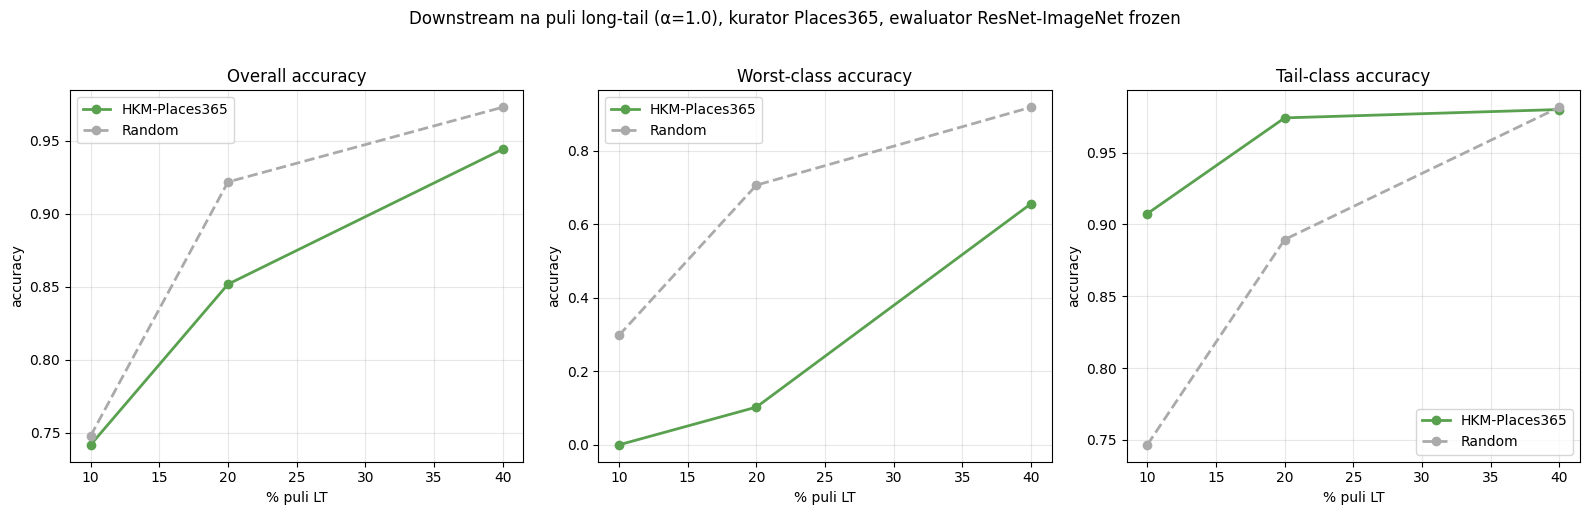

In [34]:
# ── P4. Wykres downstream: overall, worst-class i tail accuracy ───────────────
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)

for ax, metric, title in zip(
    axes,
    ['overall', 'worst_class', 'tail_acc'],
    ['Overall accuracy', 'Worst-class accuracy', 'Tail-class accuracy']
):
    for method, color, linestyle in [
        ('HKM-Places365', '#59a14f', '-'),
        ('Random', '#aaaaaa', '--')
    ]:
        d = e3_places_df[
            e3_places_df.method == method
        ].sort_values('budget')

        ax.plot(
            d.budget * 100,
            d[metric],
            marker='o',
            color=color,
            ls=linestyle,
            lw=2,
            label=method
        )

    ax.set_title(title)
    ax.set_xlabel('% puli LT')
    ax.set_ylabel('accuracy')
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle(
    f'Downstream na puli long-tail (α={a}), '
    'kurator Places365, ewaluator ResNet-ImageNet frozen',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    'e3_downstream_lt_places365.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [35]:
# ── P5. Mocniejszy ewaluator: progressive unfreeze ────────────────────────────
UNFREEZE_PLACES = [
    'fc',
    'layer4',
    'layer3',
    'layer2'
]

LAYER_LR_PLACES = {
    'layer1': 1e-5,
    'layer2': 1e-5,
    'layer3': 1e-4,
    'layer4': 1e-4,
    'fc': 1e-3
}


def load_scratch_unfreeze_places365(unfreeze_layers):
    assert art['scratch_final_weights.pt'], (
        'Brak scratch_final_weights.pt'
    )

    model = create_model('scratch', frozen=False)

    base = (
        model.module
        if isinstance(model, nn.DataParallel)
        else model
    )

    base.load_state_dict(
        torch.load(
            art['scratch_final_weights.pt'],
            map_location=device
        )
    )

    for p in base.parameters():
        p.requires_grad = False

    for layer_name in unfreeze_layers:
        for p in getattr(base, layer_name).parameters():
            p.requires_grad = True

    return model.to(device)


def run_unfreeze_places365(global_idx, epochs=EPOCHS_FROZEN):
    loader = make_loader(
        Subset(train_model_ds, global_idx),
        shuffle=True
    )

    model = load_scratch_unfreeze_places365(
        UNFREEZE_PLACES
    )

    base = (
        model.module
        if isinstance(model, nn.DataParallel)
        else model
    )

    crit = nn.CrossEntropyLoss()

    opt = torch.optim.AdamW(
        [
            {
                'params': getattr(base, layer_name).parameters(),
                'lr': LAYER_LR_PLACES[layer_name]
            }
            for layer_name in UNFREEZE_PLACES
        ],
        weight_decay=1e-4
    )

    best = 0.0

    for _ in range(epochs):
        train_one_epoch(
            model,
            loader,
            opt,
            crit,
            frozen=False
        )

        _, acc = evaluate(
            model,
            val_loader_exp,
            crit
        )

        best = max(best, acc)

    del model, opt, crit, loader
    torch.cuda.empty_cache()

    return best


a = HEADLINE_ALPHA
pool = lt_pools[a]['pool']

nclu = scaled_n_clusters(len(pool))

# Najważniejsza różnica: klastry tworzymy na podstawie Places365.
cl_lt_places = build_hkm(
    places_feats[pool],
    n_clusters=nclu
)

rng = np.random.default_rng(SEED)
random_order = rng.permutation(len(pool))

target = int(round(len(pool) * 0.20))

e5_places_rows = []

for method, global_idx in [
    (
        'HKM-Places365',
        pool[hkm_subset(cl_lt_places, target)]
    ),
    (
        'Random',
        pool[random_order[:target]]
    )
]:
    acc = run_unfreeze_places365(global_idx)

    e5_places_rows.append(
        dict(
            alpha=a,
            budget=0.20,
            method=method,
            config='+'.join(UNFREEZE_PLACES),
            best_val_acc=acc
        )
    )

    print(
        f'  {method:13s} '
        f'best_val_acc={acc:.4f}'
    )

e5_places_df = pd.DataFrame(e5_places_rows)

e5_places_df.to_csv(
    'e5_unfreeze_lt_places365.csv',
    index=False
)

print(e5_places_df.to_markdown(index=False))

Hierarchical sampling from clusters: 100%|██████████| 31/31 [00:00<00:00, 2871.48it/s]


  HKM-Places365 best_val_acc=0.8668


KeyboardInterrupt: 

Hierarchical sampling from clusters: 100%|██████████| 31/31 [00:00<00:00, 1817.95it/s]
t-SNE puli LT w przestrzeni Places365...


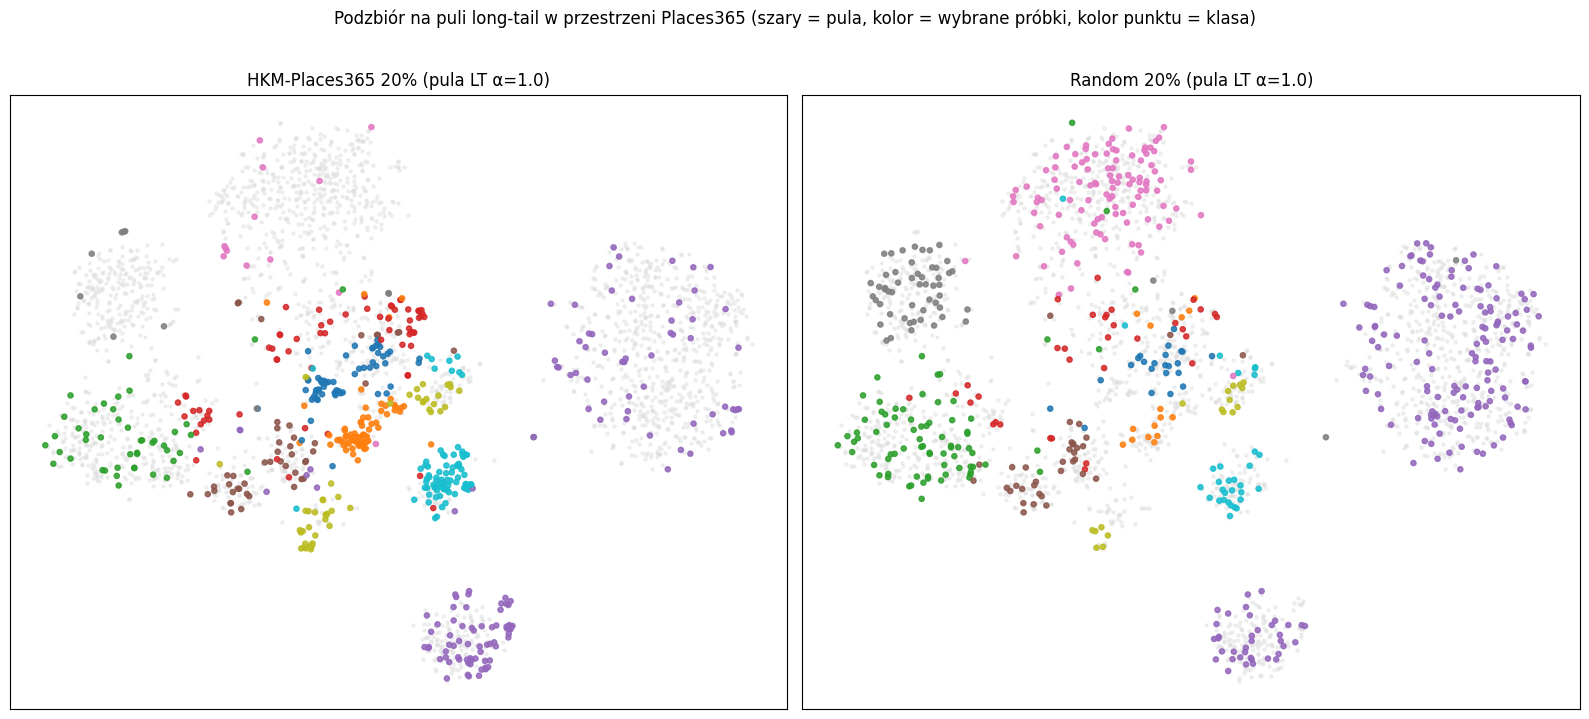

In [36]:
# ── P6. t-SNE embeddingów Places365: HKM-Places365 vs Random ─────────────────
from sklearn.manifold import TSNE

a = HEADLINE_ALPHA
pool = lt_pools[a]['pool']

places_pool = places_feats[pool]
lab_pool_places = train_labels[pool]

nclu = scaled_n_clusters(len(pool))

cl_lt_places = build_hkm(
    places_pool,
    n_clusters=nclu
)

rng = np.random.default_rng(SEED)
random_order = rng.permutation(len(pool))

target = int(round(len(pool) * 0.20))

hkm_local_places = hkm_subset(
    cl_lt_places,
    target
)

rnd_local_places = random_order[:target]

print('t-SNE puli LT w przestrzeni Places365...')

emb2d_places = TSNE(
    n_components=2,
    perplexity=40,
    random_state=SEED,
    n_jobs=-1
).fit_transform(places_pool)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7)
)

for ax, local_idx, title in [
    (
        axes[0],
        hkm_local_places,
        'HKM-Places365 20%'
    ),
    (
        axes[1],
        rnd_local_places,
        'Random 20%'
    )
]:
    ax.scatter(
        emb2d_places[:, 0],
        emb2d_places[:, 1],
        c='#dddddd',
        s=5,
        alpha=0.4
    )

    ax.scatter(
        emb2d_places[local_idx, 0],
        emb2d_places[local_idx, 1],
        c=lab_pool_places[local_idx],
        cmap='tab10',
        s=14,
        alpha=0.85,
        vmin=0,
        vmax=9
    )

    ax.set_title(
        f'{title} (pula LT α={a})'
    )

    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(
    'Podzbiór na puli long-tail w przestrzeni Places365 '
    '(szary = pula, kolor = wybrane próbki, kolor punktu = klasa)',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    'e6_tsne_lt_subset_places365.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

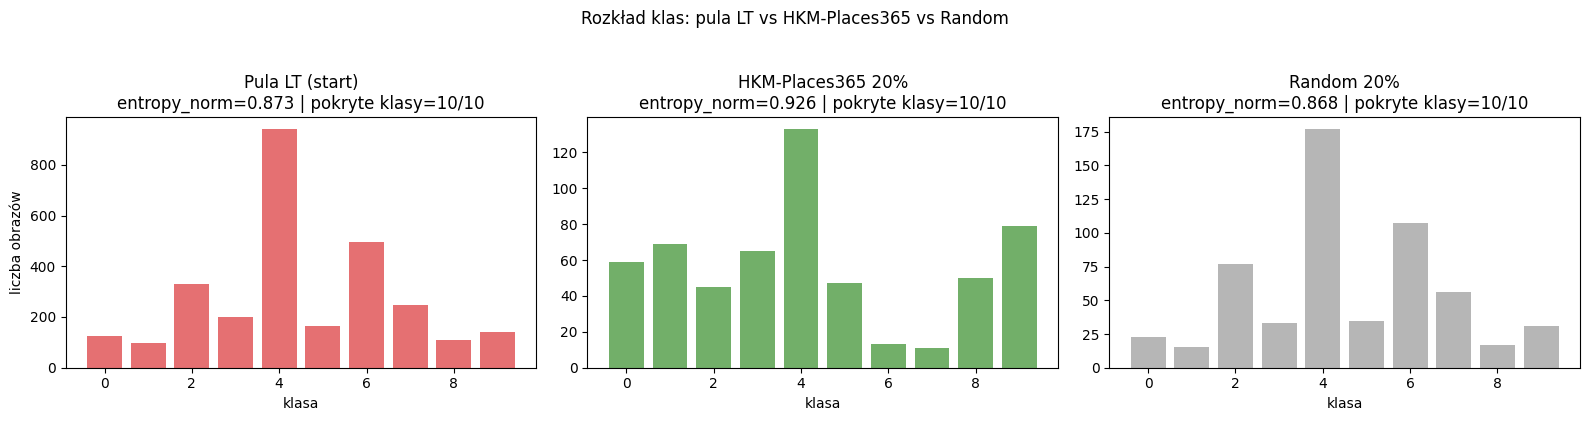

In [37]:
# ── P7. Histogramy klas: pula LT vs HKM-Places365 vs Random ──────────────────
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4),
    sharey=False
)

for ax, labels, title, color in [
    (
        axes[0],
        lab_pool_places,
        'Pula LT (start)',
        '#e15759'
    ),
    (
        axes[1],
        lab_pool_places[hkm_local_places],
        'HKM-Places365 20%',
        '#59a14f'
    ),
    (
        axes[2],
        lab_pool_places[rnd_local_places],
        'Random 20%',
        '#aaaaaa'
    )
]:
    counts = np.bincount(
        labels,
        minlength=num_classes
    )

    ax.bar(
        range(num_classes),
        counts,
        color=color,
        alpha=0.85
    )

    metrics = balance_metrics(labels)

    ax.set_title(
        f'{title}\n'
        f'entropy_norm={metrics["entropy_norm"]:.3f} | '
        f'pokryte klasy={metrics["classes_covered"]}/{num_classes}'
    )

    ax.set_xlabel('klasa')

axes[0].set_ylabel('liczba obrazów')

plt.suptitle(
    'Rozkład klas: pula LT vs HKM-Places365 vs Random',
    y=1.04
)

plt.tight_layout()

plt.savefig(
    'e6_subset_hist_lt_places365.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## 9. Eksport

Wszystkie CSV/PNG zapisane w `/kaggle/working`. Wyniki ze starego notebooka
(`results_df`, progressive unfreeze, Places365-jako-ewaluator) kopiujesz z jego outputów
i wklejasz obok nowych do raportu.

In [ ]:
import glob
print('Pliki wynikowe:')
for f in sorted(glob.glob('e*.csv') + glob.glob('e*_*.png') + ['e4_hkm_places_balanced.csv']):
    if os.path.exists(f):
        print(' ', f)
print('\nGotowe.')

Liczę t-SNE dla 3 przestrzeni (~1-2 min)...


/tmp/ipykernel_58/3781567735.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab10', 10)


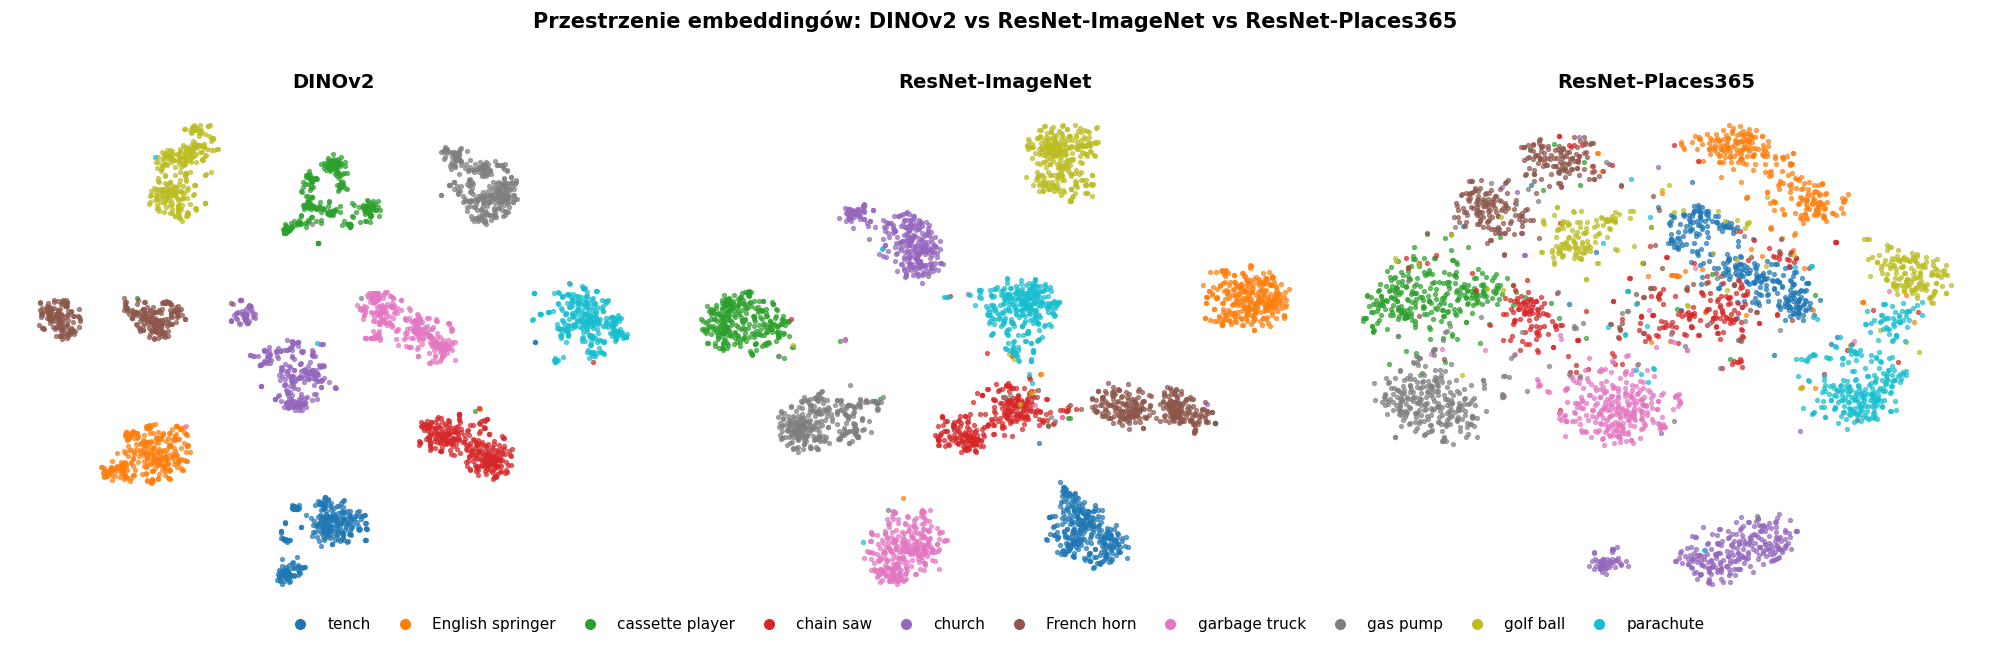

Zapisano: tsne_3_przestrzenie.png


In [12]:
import numpy as np, glob, os, matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ── 1. Nazwy klas (Imagenette, posortowane alfabetycznie jak ImageFolder) ──────
CLASS_NAMES = {
    0: "tench",          1: "English springer", 2: "cassette player",
    3: "chain saw",      4: "church",           5: "French horn",
    6: "garbage truck",  7: "gas pump",         8: "golf ball",
    9: "parachute"
}

# ── 2. Załaduj embeddingi ───────────────────────────────────────────────────────
def find(name):
    hits = glob.glob(f'/kaggle/**/{name}', recursive=True) + \
           glob.glob(f'./{name}') + glob.glob(f'/kaggle/working/{name}')
    return hits[0] if hits else None

labels       = np.load(find('train_labels_emb.npy'))
embs = {
    'DINOv2':          np.load(find('train_embeddings.npy')),
    'ResNet-ImageNet': np.load(find('resnet_feats.npy')),
    'ResNet-Places365':np.load(find('places_feats.npy')),
}

# ── 3. t-SNE (subsample do 3000 dla szybkości, zachowując proporcje klas) ──────
N_SUB = 3000
rng = np.random.default_rng(42)
idx = np.concatenate([rng.choice(np.where(labels==c)[0],
       size=N_SUB//10, replace=False) for c in range(10)])
lab_sub = labels[idx]

print("Liczę t-SNE dla 3 przestrzeni (~1-2 min)...")
tsnes = {name: TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
                   .fit_transform(emb[idx]) for name, emb in embs.items()}

# ── 4. Wykres ───────────────────────────────────────────────────────────────────
cmap   = plt.cm.get_cmap('tab10', 10)
colors = [cmap(c) for c in range(10)]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('white')

for ax, (name, xy) in zip(axes, tsnes.items()):
    for c in range(10):
        mask = lab_sub == c
        ax.scatter(xy[mask, 0], xy[mask, 1], c=[colors[c]],
                   s=8, alpha=0.65, rasterized=True)
    ax.set_title(name, fontsize=14, fontweight='bold', pad=10)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[['top','right','left','bottom']].set_visible(False)

# jedna wspólna legenda pod wykresami
handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=colors[c], markersize=9, label=CLASS_NAMES[c])
           for c in range(10)]
fig.legend(handles=handles, ncol=10, loc='lower center',
           bbox_to_anchor=(0.5, -0.04), fontsize=11,
           frameon=False, columnspacing=1.2)

plt.suptitle("Przestrzenie embeddingów: DINOv2 vs ResNet-ImageNet vs ResNet-Places365",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tsne_3_przestrzenie.png', dpi=180, bbox_inches='tight')
plt.show()
print("Zapisano: tsne_3_przestrzenie.png")

N=9469 | target 20% = 1894 próbek
Buduję HKM dla każdej przestrzeni embeddingów...
  HKM na DINOv2... 

/tmp/ipykernel_58/1048637107.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab10', 10)


Hierarchical sampling from clusters: 100%|██████████| 100/100 [00:00<00:00, 4008.16it/s]
OK — wybrano 1894 próbek
Hierarchical sampling from clusters: 100%|██████████| 100/100 [00:00<00:00, 4448.49it/s]
OK — wybrano 1894 próbek
Hierarchical sampling from clusters: 100%|██████████| 100/100 [00:00<00:00, 3078.28it/s]
OK — wybrano 1894 próbek
Random (DINOv2): 1894 próbek, seed=42
Random (ResNet-ImageNet): 1894 próbek, seed=43
Random (ResNet-Places365): 1894 próbek, seed=44

Liczę t-SNE (~2-3 min)...
  t-SNE: DINOv2 (4601 punktów)... OK
  t-SNE: ResNet-ImageNet (4642 punktów)... OK
  t-SNE: ResNet-Places365 (4618 punktów)... OK


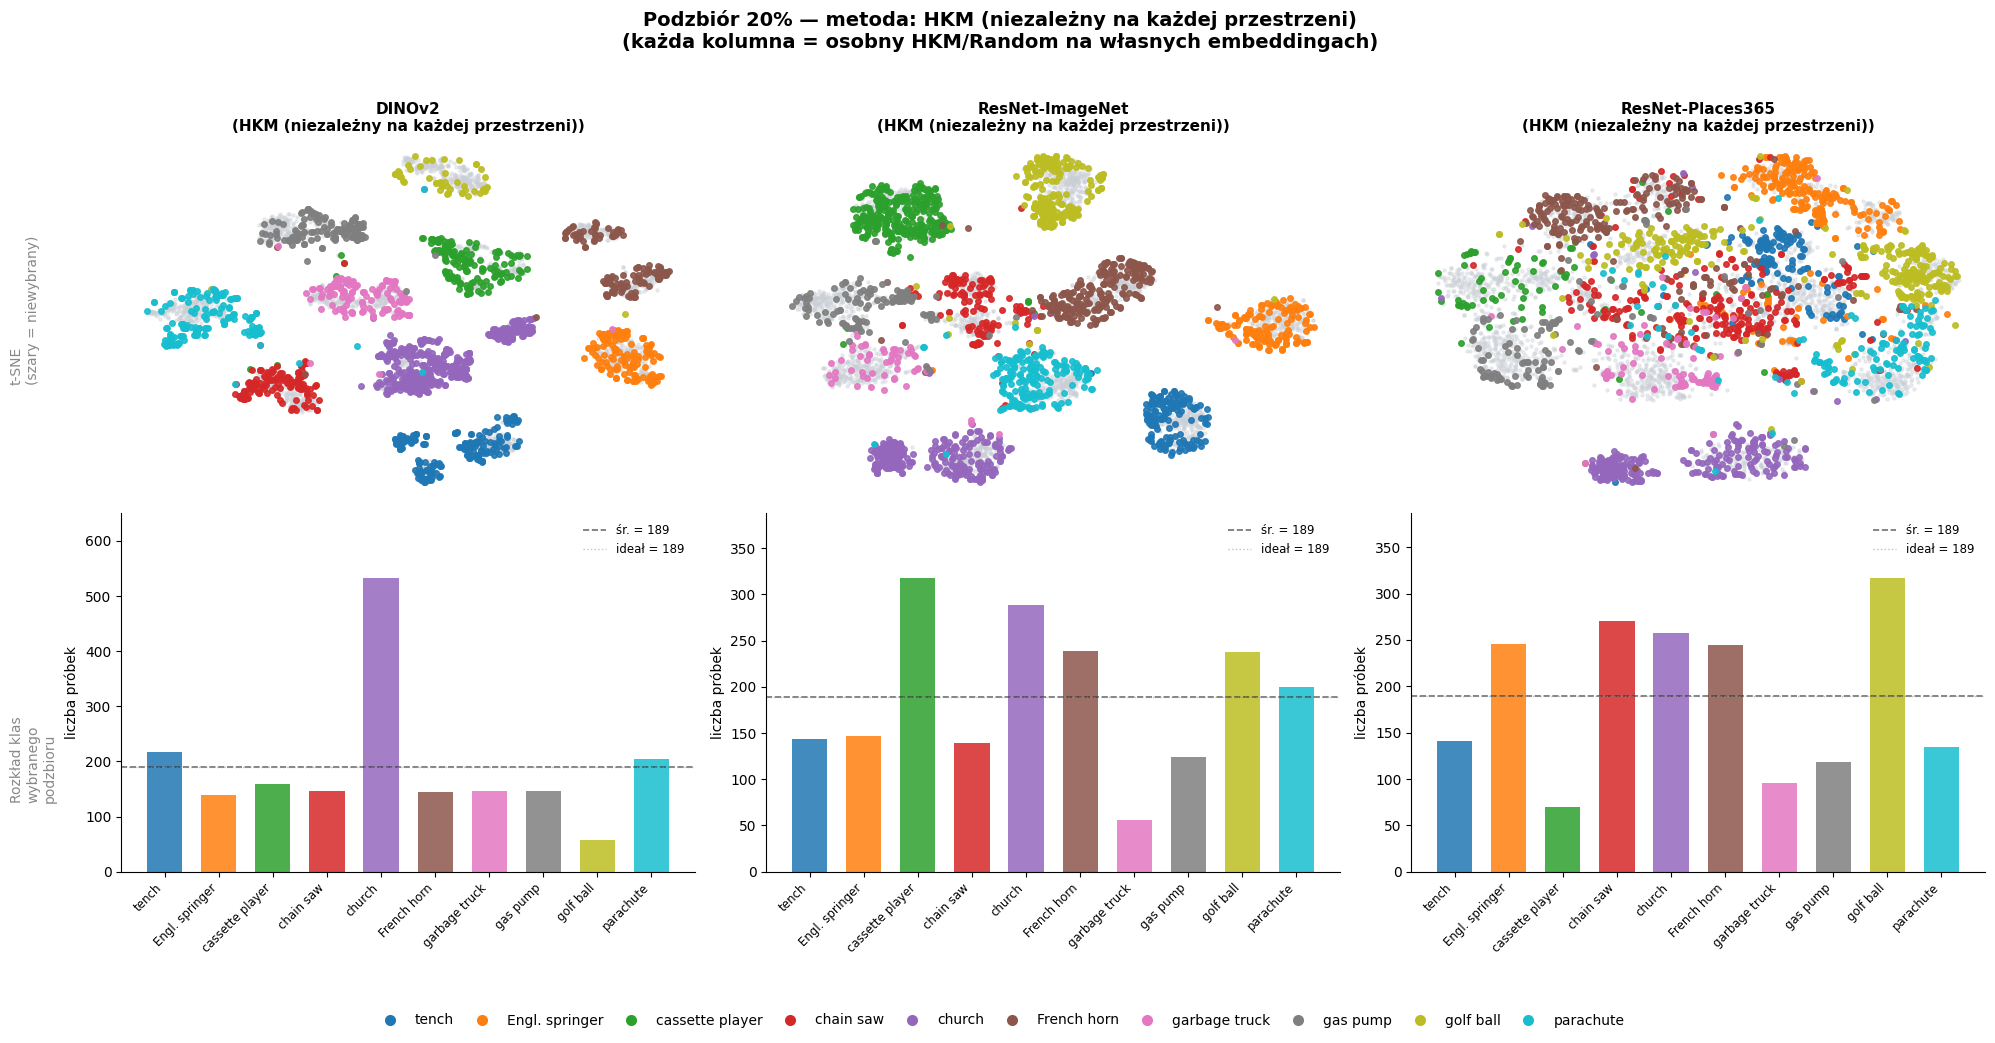

Zapisano: slajd_hkm_20pct.png


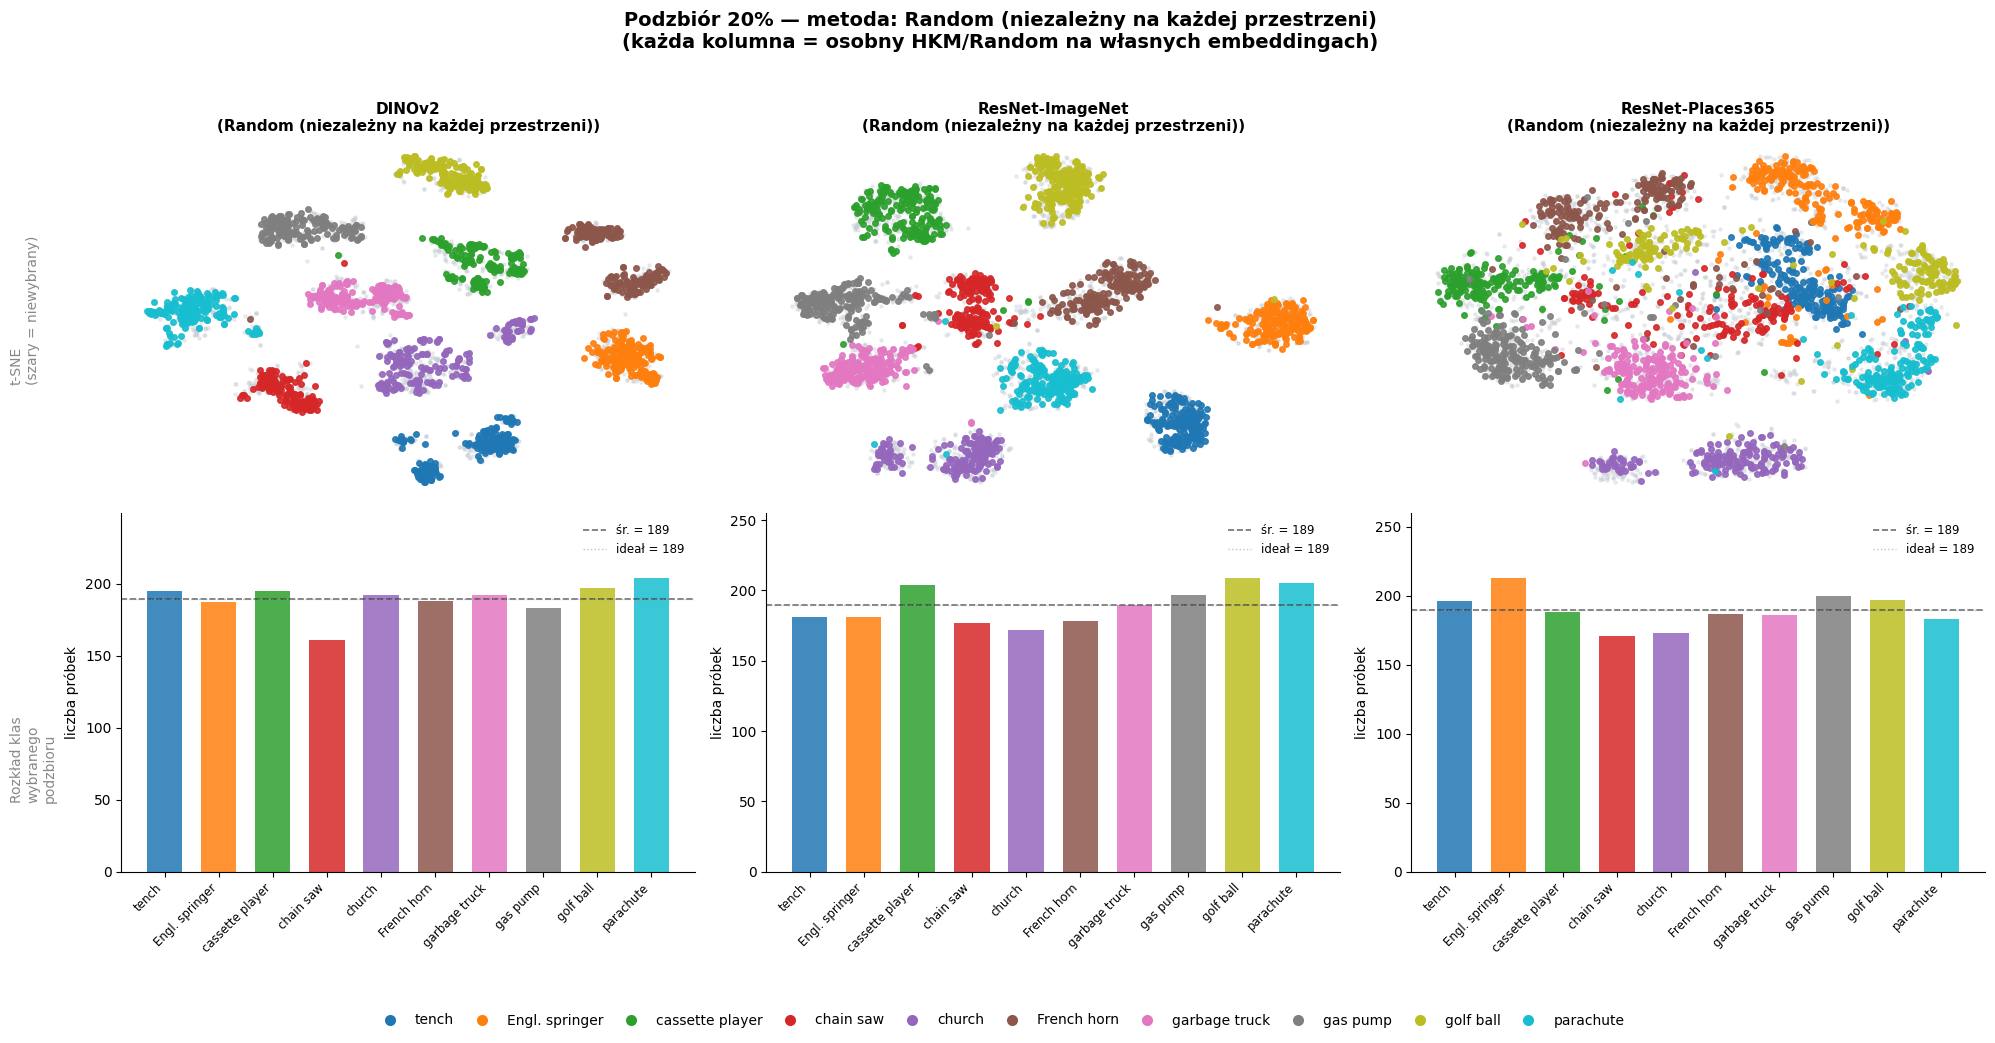

Zapisano: slajd_random_20pct.png


In [14]:
import numpy as np, glob, pickle, os, torch, torch.nn.functional as F, matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import sys
sys.path.insert(0, '/kaggle/working/ssl-data-curation')
np.Inf = np.inf
from src.clusters import HierarchicalCluster
from src import hierarchical_kmeans_gpu as hkmg, hierarchical_sampling as hs

SEED = 42
CLASS_NAMES = ["tench", "Engl. springer", "cassette player", "chain saw",
               "church", "French horn", "garbage truck", "gas pump",
               "golf ball", "parachute"]
cmap   = plt.cm.get_cmap('tab10', 10)
COLORS = [cmap(c) for c in range(10)]
FRAC   = 0.20
DEVICE = 'cuda:0'

# ── 1. Załaduj embeddingi i etykiety ────────────────────────────────────────────
def find(name):
    hits = glob.glob(f'/kaggle/**/{name}', recursive=True) + \
           [f'/kaggle/working/{name}']
    return next((h for h in hits if os.path.exists(h)), None)

labels = np.load(find('train_labels_emb.npy'))
N      = len(labels)
TARGET = int(round(N * FRAC))

EMBS = {
    'DINOv2':           np.load(find('train_embeddings.npy')),
    'ResNet-ImageNet':  np.load(find('resnet_feats.npy')),
    'ResNet-Places365': np.load(find('places_feats.npy')),
}
print(f"N={N} | target 20% = {TARGET} próbek")

# ── 2. Trzy osobne HKM (każdy na swoich embeddingach) ───────────────────────────
def run_hkm(emb, seed=SEED):
    np.random.seed(seed); torch.manual_seed(seed)
    data = torch.tensor(np.ascontiguousarray(emb),
                        device=DEVICE, dtype=torch.float32)
    cl = HierarchicalCluster.from_dict(
        hkmg.hierarchical_kmeans_with_resampling(
            data=data, n_clusters=[1000, 300, 100],
            n_levels=3, sample_sizes=[5, 3, 2], verbose=False))
    np.random.seed(seed); torch.manual_seed(seed)
    return np.array(hs.hierarchical_sampling(cl, target_size=TARGET,
                                              sampling_strategy='r'))

print("Buduję HKM dla każdej przestrzeni embeddingów...")
HKM_IDX = {}
for name, emb in EMBS.items():
    print(f"  HKM na {name}...", end=' ', flush=True)
    HKM_IDX[name] = run_hkm(emb)
    print(f"OK — wybrano {len(HKM_IDX[name])} próbek")

# ── 3. Trzy niezależne losowania Random (różne seedy) ───────────────────────────
RND_IDX = {}
for i, name in enumerate(EMBS.keys()):
    rng = np.random.default_rng(SEED + i)          # seed 42, 43, 44
    RND_IDX[name] = rng.choice(N, size=TARGET, replace=False)
    print(f"Random ({name}): {len(RND_IDX[name])} próbek, seed={SEED+i}")

# ── 4. t-SNE — dla każdej przestrzeni osobno (subsampling: wybrany + szare tło) ─
# Dla każdej przestrzeni bierzemy HKM_IDX ∪ RND_IDX tej przestrzeni + szare tło
# żeby obie figury (HKM / Random) miały te same współrzędne t-SNE → porównywalne

print("\nLiczę t-SNE (~2-3 min)...")
TSNES   = {}   # {space_name: xy}  — na połączonym zbiorze
VIZ_IDX = {}   # {space_name: viz_idx}
IN_HKM  = {}   # {space_name: bool mask}
IN_RND  = {}

for name, emb in EMBS.items():
    hkm_i = HKM_IDX[name]
    rnd_i = RND_IDX[name]
    all_sel  = np.union1d(hkm_i, rnd_i)
    grey_pool = np.setdiff1d(np.arange(N), all_sel)
    grey_i    = np.random.default_rng(0).choice(grey_pool, size=1200, replace=False)
    viz_idx   = np.concatenate([all_sel, grey_i])

    VIZ_IDX[name] = viz_idx
    IN_HKM[name]  = np.isin(viz_idx, hkm_i)
    IN_RND[name]  = np.isin(viz_idx, rnd_i)

    print(f"  t-SNE: {name} ({len(viz_idx)} punktów)...", end=' ', flush=True)
    TSNES[name] = TSNE(n_components=2, perplexity=40,
                       random_state=SEED, n_jobs=-1).fit_transform(emb[viz_idx])
    print("OK")

# ── 5. Funkcja rysująca figurę 2×3 ─────────────────────────────────────────────
def make_fig(sel_idx_dict, sel_mask_dict, method_name, fname):
    """
    sel_idx_dict  : {space_name: array of selected global indices}
    sel_mask_dict : {space_name: bool mask over viz_idx}
    """
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    fig.patch.set_facecolor('white')

    for col, space in enumerate(EMBS.keys()):
        xy      = TSNES[space]
        viz_idx = VIZ_IDX[space]
        sel_m   = sel_mask_dict[space]
        sub_idx = sel_idx_dict[space]
        lab_viz = labels[viz_idx]

        # --- wiersz 1: t-SNE ---
        ax = axes[0, col]
        ax.scatter(xy[~sel_m, 0], xy[~sel_m, 1],
                   c='#CACFD6', s=5, alpha=0.35, rasterized=True, zorder=1)
        for c in range(10):
            m = sel_m & (lab_viz == c)
            ax.scatter(xy[m, 0], xy[m, 1], c=[COLORS[c]],
                       s=16, alpha=0.9, rasterized=True, zorder=2)
        ax.set_title(f"{space}\n({method_name})", fontsize=11,
                     fontweight='bold', pad=6)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)

        # --- wiersz 2: rozkład klas wybranego podzbioru ---
        ax2 = axes[1, col]
        counts = np.bincount(labels[sub_idx], minlength=10)
        ax2.bar(range(10), counts, color=COLORS, alpha=0.85, width=0.65)
        ax2.axhline(counts.mean(), color='#333', ls='--', lw=1.2,
                    alpha=0.7, label=f'śr. = {counts.mean():.0f}')
        ax2.axhline(TARGET / 10, color='#999', ls=':', lw=1.0,
                    alpha=0.6, label=f'ideał = {TARGET//10}')
        ax2.set_xticks(range(10))
        ax2.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8.5)
        ax2.set_ylabel('liczba próbek', fontsize=10)
        ax2.set_ylim(0, max(counts.max(), TARGET//10) * 1.22)
        ax2.legend(fontsize=8.5, frameon=False)
        for sp in ['top', 'right']: ax2.spines[sp].set_visible(False)

    # etykiety wierszy
    fig.text(0.005, 0.72, "t-SNE\n(szary = niewybrany)",
             fontsize=10, color='#888', rotation=90, va='center')
    fig.text(0.005, 0.27, "Rozkład klas\nwybranego\npodzbioru",
             fontsize=10, color='#888', rotation=90, va='center')

    # legenda klas
    handles = [plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=COLORS[c], markersize=9,
               label=CLASS_NAMES[c]) for c in range(10)]
    fig.legend(handles=handles, ncol=10, loc='lower center',
               bbox_to_anchor=(0.5, -0.01), fontsize=10,
               frameon=False, columnspacing=1.0)

    plt.suptitle(
        f"Podzbiór 20% — metoda: {method_name}\n"
        f"(każda kolumna = osobny HKM/Random na własnych embeddingach)",
        fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout(rect=[0.025, 0.06, 1, 1])
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Zapisano: {fname}")

# ── 6. Generuj obie figury ──────────────────────────────────────────────────────
make_fig(HKM_IDX, IN_HKM, "HKM (niezależny na każdej przestrzeni)", "slajd_hkm_20pct.png")
make_fig(RND_IDX, IN_RND, "Random (niezależny na każdej przestrzeni)", "slajd_random_20pct.png")